# NDB-UFES Dataset Statistics and Visual Factsheet

This notebook creates visual summaries for the NDB-UFES data organizer. It is meant for public dataset documentation, not downstream model training.

It shows and saves graphs for:

- diagnosis and task-label distributions;
- demographic and clinical variable distributions;
- missingness / `Not informed` rates;
- variable association heatmaps;
- age-group skew and diagnosis relationships;
- lesion size summaries;
- ROI/coordinate coverage examples are deferred until patch-origin-coordinate associations are rerun;
- provisional fold characteristics, when fold files are available.

All figures are saved to `results/dataset_statistics/`.

In [29]:
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PATCH_METADATA = PROJECT_ROOT / "data/ndb_ufes/patch/parcial_pndb_ufes.csv"
ORIGIN_METADATA = PROJECT_ROOT / "data/ndb_ufes/origin_level/csvs/ndb-ufes.csv"

PROVISIONAL_ORIGIN_FOLDS = PROJECT_ROOT / "data/ndb_ufes/origin_level/csvs/fold_assignments_origin.csv"
PROVISIONAL_PATCH_FOLDS = PROJECT_ROOT / "data/ndb_ufes/patch_level/csvs/fold_assignments_patch_level_with_images.csv"

OUT_DIR = PROJECT_ROOT / "results/dataset_statistics"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Output directory:", OUT_DIR)

Project root: /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer
Output directory: /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics


## Load Data

The patch metadata is the main table for patch-level statistics. The origin metadata is useful for source-level counts from the original NDB-UFES metadata.

In [30]:
patch_df = pd.read_csv(PATCH_METADATA)
origin_df = pd.read_csv(ORIGIN_METADATA)

patch_df["origin"] = patch_df["origin"].astype(str).str.zfill(4)
origin_df["public_id"] = origin_df["public_id"].astype(str).str.zfill(4)

AGE_LABELS = {
    "0": "< 40 years",
    "1": "40-60 years",
    "2": "> 60 years",
}
patch_df["age_group_label"] = patch_df["age_group"].astype(str).map(AGE_LABELS).fillna(patch_df["age_group"].astype(str))
origin_df["age_group_label"] = origin_df["age_group"].astype(str).map(AGE_LABELS).fillna(origin_df["age_group"].astype(str))

matched_origin_ids = set(patch_df["origin"].astype(str).str.zfill(4))
matched_origin_df = origin_df[origin_df["public_id"].isin(matched_origin_ids)].copy()

COORDINATES_NEED_RERUN = True
# Coordinate-derived ROI fields are intentionally not recomputed here.
# Some patches were previously associated with the wrong origin, and these coordinates
# belong to that earlier association. Recompute patch-origin-coordinate links before
# plotting ROI coverage on origin images.

print("Patch metadata:", patch_df.shape)
print("Origin metadata:", origin_df.shape)
print("Matched origins represented in patch metadata:", matched_origin_df.shape)
display(patch_df.head())

Patch metadata: (3086, 24)
Origin metadata: (237, 18)
Matched origins represented in patch metadata: (203, 18)


,patch,origin,public_id,lesion_id,patient_id,path,localization,larger_size,tobacco_use,alcohol_consumption,...,diagnosis,dysplasia_severity,TaskII,TaskIII,TaskIV,top_left_x,top_left_y,bottom_right_x,bottom_right_y,age_group_label
0,p0000,0041,41,84,78,0041.png,Tongue,0.4,No,Yes,...,Leukoplakia with dysplasia,Mild,Leukoplakia,Presence,Leukoplakia with dysplasia,81.0,-1024.0,593.0,1536.0,40-60 years
1,p0001,0041,41,84,78,0041.png,Tongue,0.4,No,Yes,...,Leukoplakia with dysplasia,Mild,Leukoplakia,Presence,Leukoplakia with dysplasia,717.0,-751.0,1229.0,1263.0,40-60 years
2,p0002,0041,41,84,78,0041.png,Tongue,0.4,No,Yes,...,Leukoplakia with dysplasia,Mild,Leukoplakia,Presence,Leukoplakia with dysplasia,616.0,-677.0,1128.0,1189.0,40-60 years
3,p0003,0041,41,84,78,0041.png,Tongue,0.4,No,Yes,...,Leukoplakia with dysplasia,Mild,Leukoplakia,Presence,Leukoplakia with dysplasia,1442.0,-729.0,1954.0,1241.0,40-60 years
4,p0004,0041,41,84,78,0041.png,Tongue,0.4,No,Yes,...,Leukoplakia with dysplasia,Mild,Leukoplakia,Presence,Leukoplakia with dysplasia,1300.0,-577.0,1812.0,1089.0,40-60 years


In [31]:
def save_fig(name, fig=None):
    fig = fig or plt.gcf()
    path = OUT_DIR / name
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print("saved", path)


BASE_COLORS = {
    # Diagnostic/task labels keep stable colors for cross-figure recognition.
    "OSCC": "#D55E00",
    "Leukoplakia with dysplasia": "#0072B2",
    "Leukoplakia without dysplasia": "#009E73",
    "Leukoplakia": "#CC79A7",
    "Presence": "#E69F00",
    "Absence": "#56B4E9",

    # Demographic and clinical metadata use arbitrary categorical colors.
    "M": "#6B6ECF",
    "F": "#B5CF6B",
    "White": "#17BECF",
    "Black": "#BCBD22",
    "Brown": "#9467BD",
    "< 40 years": "#8CD17D",
    "40-60 years": "#B6992D",
    "> 60 years": "#499894",
    "Yes": "#9C755F",
    "No": "#BAB0AC",
    "Former": "#F28E2B",
    "Not informed": "#9D9D9D",
    "Missing": "#C7C7C7",
}

VARIABLE_PALETTES = {
    "diagnosis": BASE_COLORS,
    "class": BASE_COLORS,
    "TaskII": BASE_COLORS,
    "TaskIII": BASE_COLORS,
    "TaskIV": BASE_COLORS,
    "gender": BASE_COLORS,
    "skin_color": BASE_COLORS,
    "age_group_label": BASE_COLORS,
    "tobacco_use": BASE_COLORS,
    "alcohol_consumption": BASE_COLORS,
    "sun_exposure": BASE_COLORS,
}


def colors_for(labels, palette=None):
    palette = palette or BASE_COLORS
    fallback = sns.color_palette("tab20", n_colors=20).as_hex()
    colors = []
    for label in labels:
        label_str = str(label)
        if label_str in palette:
            colors.append(palette[label_str])
        else:
            stable_idx = sum(ord(ch) for ch in label_str) % len(fallback)
            colors.append(fallback[stable_idx])
    return colors


def palette_for(column):
    return VARIABLE_PALETTES.get(column, BASE_COLORS)


def count_table(df, column, normalize=True, order=None):
    counts = df[column].fillna("Missing").astype(str).value_counts(dropna=False)
    if order is not None:
        ordered = [str(x) for x in order if str(x) in counts.index]
        rest = [x for x in counts.index if x not in ordered]
        counts = counts.reindex(ordered + rest)
    out = counts.rename("count").to_frame()
    if normalize:
        out["percent"] = 100 * out["count"] / out["count"].sum()
    return out


def plot_counts(df, column, title=None, filename=None, order=None, ax=None):
    data = count_table(df, column, order=order)
    ax = ax or plt.gca()
    labels = list(data.index)
    sns.barplot(
        x=data["count"].values,
        y=labels,
        ax=ax,
        palette=colors_for(labels, palette_for(column)),
        hue=labels,
        legend=False,
    )
    ax.set_title(title or column)
    ax.set_xlabel("Count")
    ax.set_ylabel("")
    max_count = data["count"].max() if len(data) else 0
    ax.set_xlim(0, max_count * 1.32 if max_count else 1)
    for i, (_, row) in enumerate(data.iterrows()):
        ax.text(row["count"], i, f" {int(row['count'])} ({row['percent']:.1f}%)", va="center")
    if filename:
        save_fig(filename, ax.figure)
    return ax


def plot_count_percent_distribution(df, column, title, filename, order=None, palette=None, figsize=(9, 4.8)):
    data = count_table(df, column, order=order)
    labels = list(data.index)
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(
        x=data["count"].values,
        y=labels,
        ax=ax,
        palette=colors_for(labels, palette or palette_for(column)),
        hue=labels,
        legend=False,
    )
    ax.set_title(title)
    ax.set_xlabel("Count")
    ax.set_ylabel("")
    max_count = data["count"].max() if len(data) else 0
    ax.set_xlim(0, max_count * 1.32 if max_count else 1)
    for i, (_, row) in enumerate(data.iterrows()):
        ax.text(row["count"], i, f" {int(row['count'])} ({row['percent']:.1f}%)", va="center")
    fig.tight_layout()
    save_fig(filename, fig)
    plt.show()
    display(data)
    return data


def plot_stacked_subset_comparison(actual_df, subset_df, column, title, filename, subset_label="Matched/classifiable subset", order=None, palette=None):
    actual = count_table(actual_df, column, order=order)
    subset = count_table(subset_df, column, order=order)
    labels = list(dict.fromkeys(list(actual.index) + list(subset.index)))
    if order is not None:
        order_str = [str(y) for y in order]
        labels = [x for x in order_str if x in labels] + [x for x in labels if x not in order_str]

    rows = {
        "Actual source metadata": actual.reindex(labels).fillna(0),
        subset_label: subset.reindex(labels).fillna(0),
    }

    fig, ax = plt.subplots(figsize=(11, 4.6))
    left = np.zeros(len(rows))
    y = np.arange(len(rows))
    colors = colors_for(labels, palette or palette_for(column))

    for label, color in zip(labels, colors):
        widths = np.array([rows[row].loc[label, "percent"] for row in rows])
        counts = np.array([rows[row].loc[label, "count"] for row in rows])
        ax.barh(y, widths, left=left, label=label, color=color)
        for idx, (width, count) in enumerate(zip(widths, counts)):
            if width >= 7:
                ax.text(left[idx] + width / 2, idx, f"{int(count)}\n{width:.1f}%", ha="center", va="center", color="white", fontsize=9, fontweight="bold")
            elif width > 0:
                ax.text(left[idx] + width + 0.6, idx, f"{int(count)} ({width:.1f}%)", va="center", fontsize=8)
        left += widths

    ax.set_yticks(y)
    ax.set_yticklabels(list(rows.keys()))
    ax.set_xlim(0, 100)
    ax.set_xlabel("Percent within dataset view")
    ax.set_title(title)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2)
    fig.tight_layout()
    save_fig(filename, fig)
    plt.show()

    comparison = pd.concat({name: table for name, table in rows.items()}, names=["dataset_view", "class"])
    display(comparison)
    return comparison


def crosstab_percent(df, row, col):
    tab = pd.crosstab(df[row], df[col])
    pct = tab.div(tab.sum(axis=1), axis=0) * 100
    return tab, pct


def plot_crosstab_heatmap(df, row, col, filename, title=None, normalize="row", row_order=None, col_order=None):
    tab = pd.crosstab(df[row].fillna("Missing"), df[col].fillna("Missing"))
    if row_order is not None:
        ordered_rows = [str(x) for x in row_order if str(x) in tab.index]
        remaining_rows = [x for x in tab.index if x not in ordered_rows]
        tab = tab.reindex(ordered_rows + remaining_rows)
    if col_order is not None:
        ordered_cols = [str(x) for x in col_order if str(x) in tab.columns]
        remaining_cols = [x for x in tab.columns if x not in ordered_cols]
        tab = tab.reindex(columns=ordered_cols + remaining_cols)

    if normalize == "row":
        pct = tab.div(tab.sum(axis=1), axis=0) * 100
        values = pct
        label = "Row %"
    elif normalize == "column":
        pct = tab.div(tab.sum(axis=0), axis=1) * 100
        values = pct
        label = "Column %"
    else:
        pct = tab / tab.to_numpy().sum() * 100
        values = tab
        label = "Count"

    annotations = tab.astype(int).astype(str) + "\n" + pct.round(1).astype(str) + "%"
    fig, ax = plt.subplots(figsize=(max(8, values.shape[1] * 1.5), max(4, values.shape[0] * 0.85)))
    sns.heatmap(values, annot=annotations, fmt="", cmap="Blues", cbar_kws={"label": label}, ax=ax)
    ax.set_title(title or f"{row} by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel(row)
    save_fig(filename, fig)
    plt.show()
    return tab, pct

def plot_numeric_histogram(df, column, title, filename, bins=20, color="#4C78A8"):
    values = pd.to_numeric(df[column], errors="coerce").dropna()
    fig, ax = plt.subplots(figsize=(9, 4.8))
    counts, edges, patches = ax.hist(values, bins=bins, color=color, edgecolor="white")
    total = counts.sum()
    ax.set_title(title)
    ax.set_xlabel(column)
    ax.set_ylabel("Count")
    ymax = counts.max() if len(counts) else 0
    ax.set_ylim(0, ymax * 1.22 if ymax else 1)
    for count, left, right in zip(counts, edges[:-1], edges[1:]):
        if count <= 0:
            continue
        pct = 100 * count / total if total else 0
        ax.text((left + right) / 2, count, f"{int(count)}\n{pct:.1f}%", ha="center", va="bottom", fontsize=8)
    fig.tight_layout()
    save_fig(filename, fig)
    plt.show()
    display(values.describe().to_frame(column).T)
    return values.describe()

def plot_boxplot_with_counts(df, x, y, title, filename, order=None):
    plot_df = df[[x, y]].copy()
    plot_df[y] = pd.to_numeric(plot_df[y], errors="coerce")
    plot_df = plot_df.dropna(subset=[x, y])
    fig, ax = plt.subplots(figsize=(10, 5.5))
    sns.boxplot(data=plot_df, x=x, y=y, order=order, ax=ax, palette=colors_for(order or sorted(plot_df[x].astype(str).unique())))
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(y)
    ax.tick_params(axis="x", rotation=20)
    counts = plot_df[x].astype(str).value_counts()
    medians = plot_df.groupby(plot_df[x].astype(str))[y].median()
    total = counts.sum()
    ymax = plot_df[y].max()
    ymin = plot_df[y].min()
    y_pos = ymax + (ymax - ymin) * 0.06 if ymax > ymin else ymax + 1
    labels = order or list(counts.index)
    for i, label in enumerate(labels):
        label_str = str(label)
        count = counts.get(label_str, 0)
        pct = 100 * count / total if total else 0
        median = medians.get(label_str, np.nan)
        ax.text(i, y_pos, f"n={int(count)}\n{pct:.1f}%\nmed={median:.2f}", ha="center", va="bottom", fontsize=9)
    ax.set_ylim(top=y_pos + (ymax - ymin) * 0.12 if ymax > ymin else y_pos + 1)
    fig.tight_layout()
    save_fig(filename, fig)
    plt.show()
    return plot_df.groupby(x)[y].describe()

def cramers_v(x, y):
    table = pd.crosstab(x.fillna("Missing"), y.fillna("Missing"))
    if table.shape[0] < 2 or table.shape[1] < 2:
        return np.nan
    chi2 = chi2_contingency(table)[0]
    n = table.to_numpy().sum()
    r, k = table.shape
    return math.sqrt((chi2 / n) / max(1, min(k - 1, r - 1)))


## Core Dataset Counts

These tables are useful for checking whether documentation counts match the source metadata.

Important: the patch-level metadata used here is a matched/classifiable cut of the available patch images, not necessarily the full raw patch image inventory. This is why the notebook compares full origin metadata, matched origins, and patch rows separately before plotting distributions.


In [20]:
patch_image_dirs = [
    PROJECT_ROOT / "data/ndb_ufes/patch_level/images",
    PROJECT_ROOT / "data/ndb_ufes/patch/images",
]
raw_patch_images = sorted({p for d in patch_image_dirs if d.exists() for p in d.glob("*.png")})
raw_patch_count = len(raw_patch_images) if raw_patch_images else np.nan

summary = pd.DataFrame([
    {"level": "origin metadata (source)", "rows": len(origin_df), "unique_origins": origin_df["public_id"].nunique()},
    {"level": "matched origins represented in patch metadata", "rows": len(matched_origin_df), "unique_origins": matched_origin_df["public_id"].nunique()},
    {"level": "patch metadata (matched/classifiable cut)", "rows": len(patch_df), "unique_origins": patch_df["origin"].nunique()},
    {"level": "raw patch image files detected", "rows": raw_patch_count, "unique_origins": np.nan},
])
display(summary)

print("Patch-level distributions below describe the matched/classifiable patch metadata, not necessarily every raw patch image file.")

display(count_table(origin_df, "diagnosis"))
display(count_table(matched_origin_df, "diagnosis"))
display(count_table(patch_df, "diagnosis"))


,level,rows,unique_origins
0,origin metadata (source),237,237.0
1,matched origins represented in patch metadata,203,203.0
2,patch metadata (matched/classifiable cut),3086,203.0
3,raw patch image files detected,3763,NaN


Patch-level distributions below describe the matched/classifiable patch metadata, not necessarily every raw patch image file.


,count,percent
diagnosis,,
OSCC,91,38.396624
Leukoplakia with dysplasia,89,37.552743
Leukoplakia without dysplasia,57,24.050633


,count,percent
diagnosis,,
OSCC,81,39.901478
Leukoplakia with dysplasia,72,35.467980
Leukoplakia without dysplasia,50,24.630542


,count,percent
diagnosis,,
OSCC,1517,49.157485
Leukoplakia with dysplasia,930,30.136099
Leukoplakia without dysplasia,639,20.706416


## Diagnosis and Task Label Distributions

Origin-level and patch-level views are paired below. Each graph is saved independently so it can be used in the factsheet or documentation on its own.

The task-label plots are preserved for context from the previous study. They are not the current modeling focus of this data organizer.


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/01a_origin_diagnosis_actual_vs_matched_stacked.png


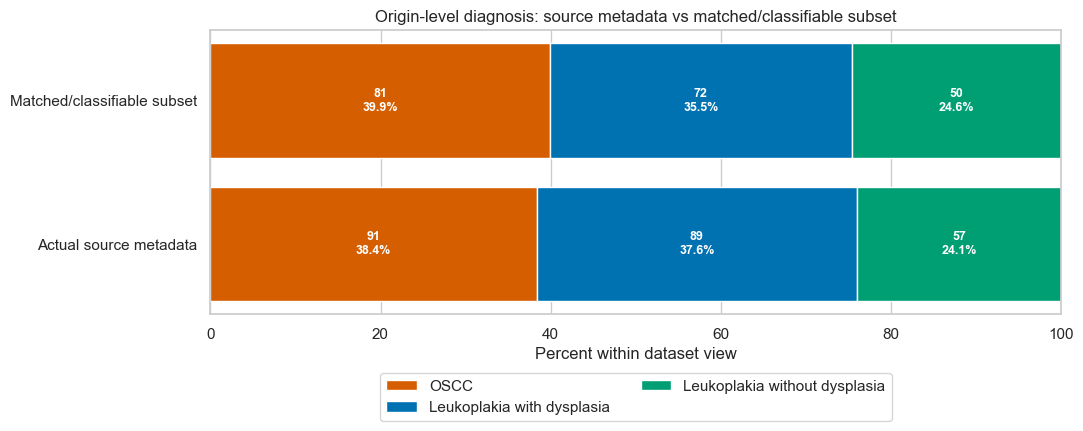

count    percent
dataset_view                class                                          
Actual source metadata      OSCC                              91  38.396624
                            Leukoplakia with dysplasia        89  37.552743
                            Leukoplakia without dysplasia     57  24.050633
Matched/classifiable subset OSCC                              81  39.901478
                            Leukoplakia with dysplasia        72  35.467980
                            Leukoplakia without dysplasia     50  24.630542

saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/01b_origin_diagnosis_matched_count_percent.png


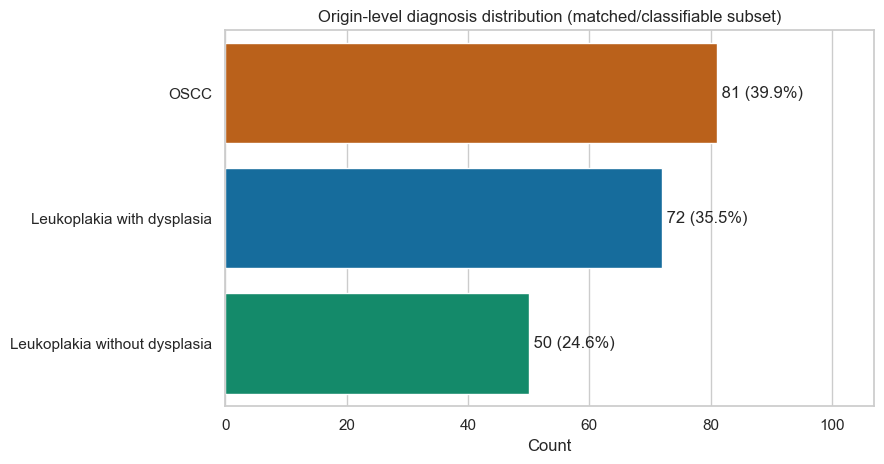

,count,percent
diagnosis,,
OSCC,81,39.901478
Leukoplakia with dysplasia,72,35.467980
Leukoplakia without dysplasia,50,24.630542


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/01c_patch_diagnosis_matched_count_percent.png


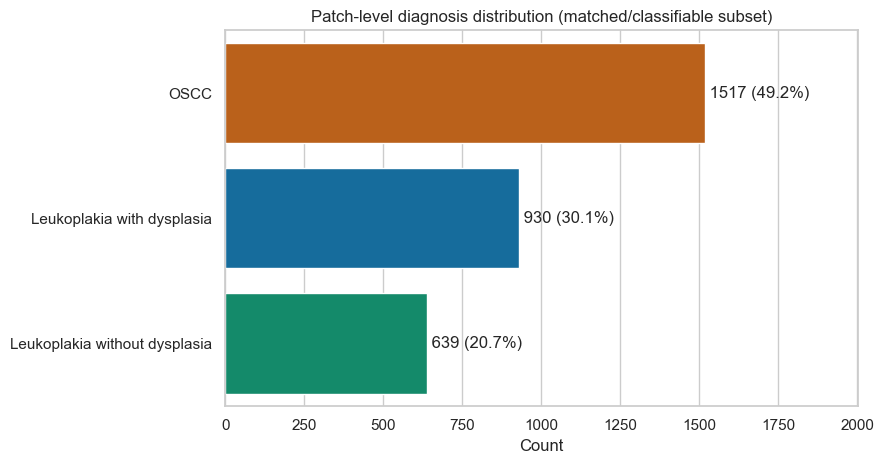

,count,percent
diagnosis,,
OSCC,1517,49.157485
Leukoplakia with dysplasia,930,30.136099
Leukoplakia without dysplasia,639,20.706416


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/02a_taskii_origin_count_percent.png


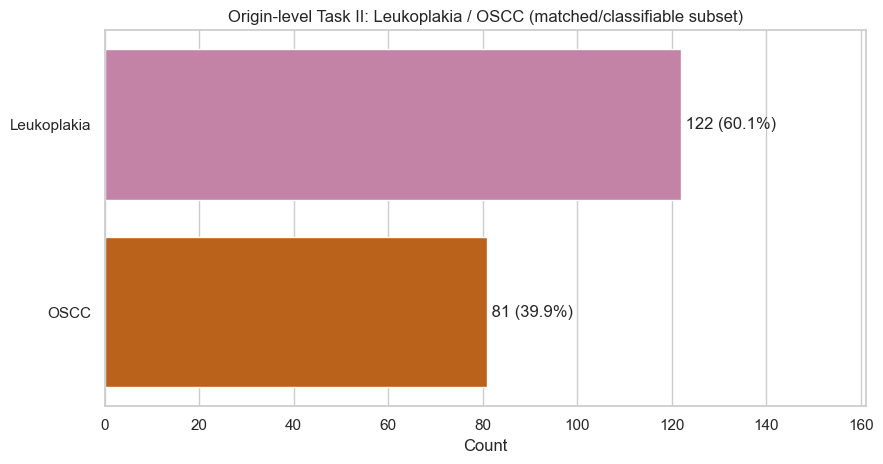

,count,percent
TaskII,,
Leukoplakia,122,60.098522
OSCC,81,39.901478


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/02a_taskii_patch_count_percent.png


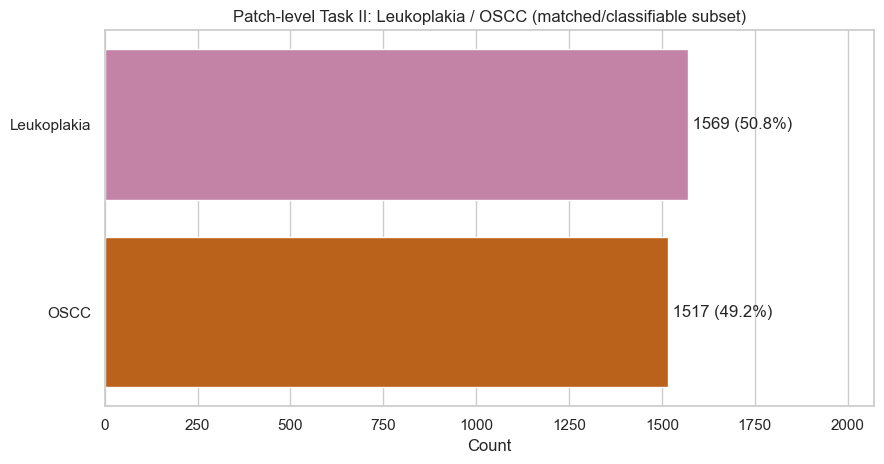

,count,percent
TaskII,,
Leukoplakia,1569,50.842515
OSCC,1517,49.157485


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/02b_taskiii_origin_count_percent.png


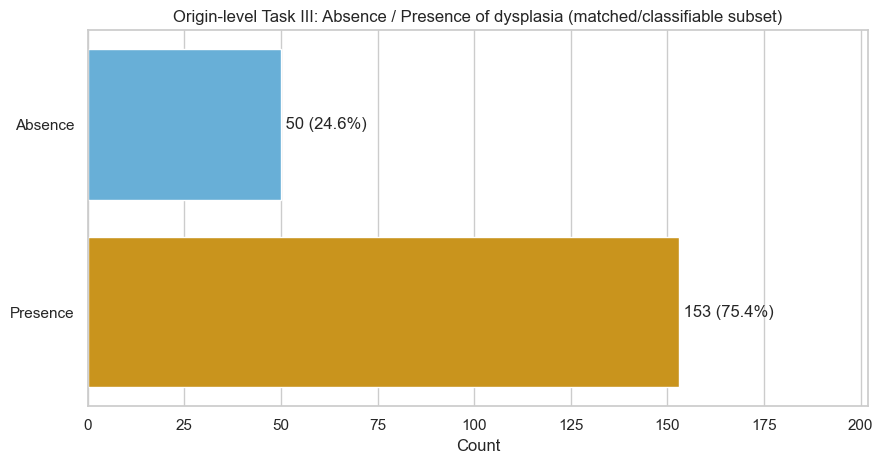

,count,percent
TaskIII,,
Absence,50,24.630542
Presence,153,75.369458


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/02b_taskiii_patch_count_percent.png


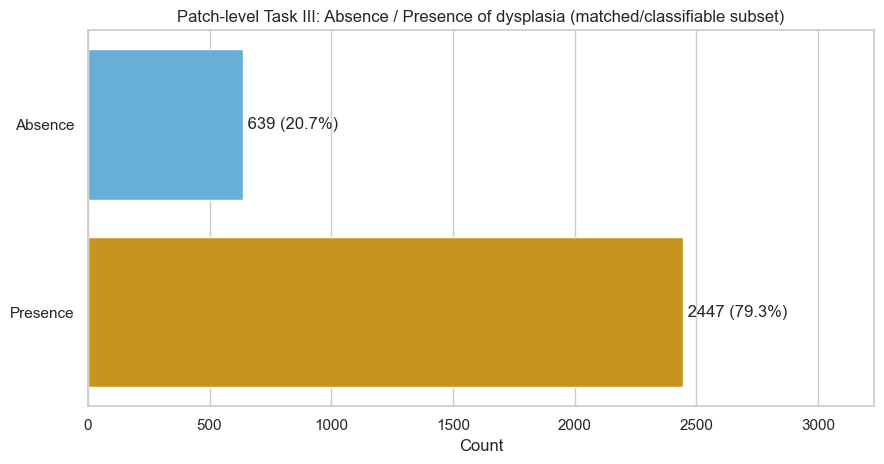

,count,percent
TaskIII,,
Absence,639,20.706416
Presence,2447,79.293584


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/02c_taskiv_origin_count_percent.png


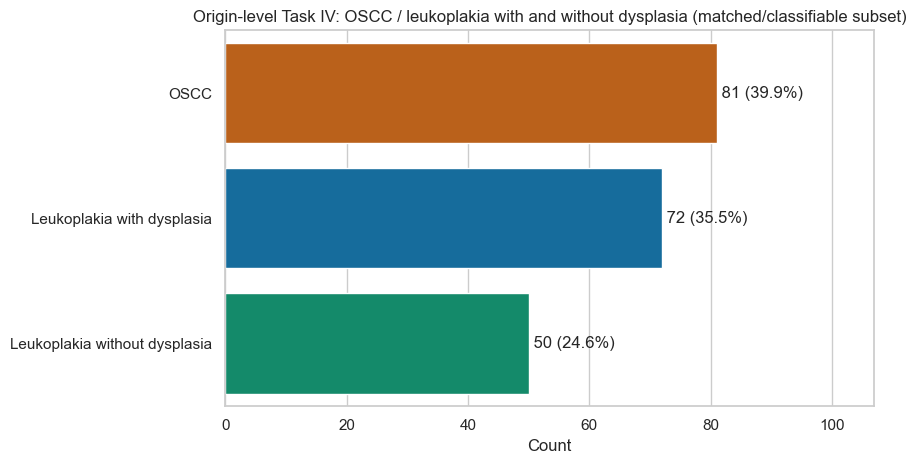

,count,percent
TaskIV,,
OSCC,81,39.901478
Leukoplakia with dysplasia,72,35.467980
Leukoplakia without dysplasia,50,24.630542


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/02c_taskiv_patch_count_percent.png


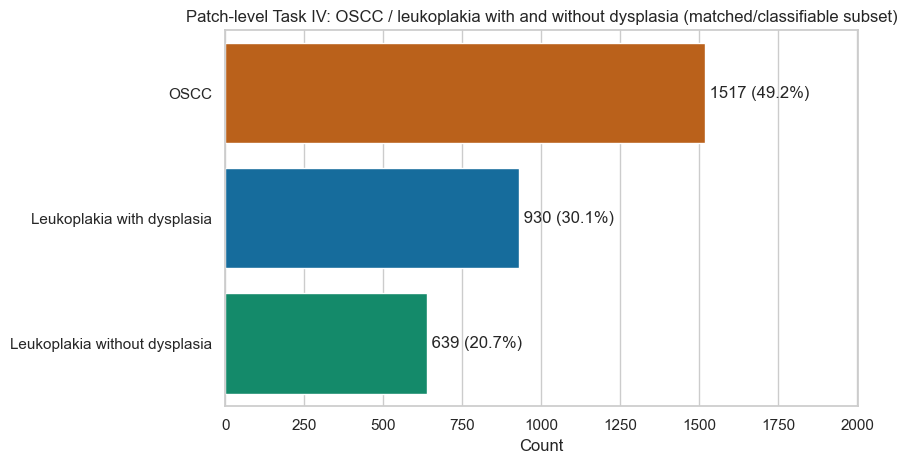

,count,percent
TaskIV,,
OSCC,1517,49.157485
Leukoplakia with dysplasia,930,30.136099
Leukoplakia without dysplasia,639,20.706416


In [32]:
diagnosis_order = [
    "OSCC",
    "Leukoplakia with dysplasia",
    "Leukoplakia without dysplasia",
]

# Actual source metadata versus matched/classifiable origin subset.
origin_diagnosis_comparison = plot_stacked_subset_comparison(
    origin_df,
    matched_origin_df,
    "diagnosis",
    "Origin-level diagnosis: source metadata vs matched/classifiable subset",
    "01a_origin_diagnosis_actual_vs_matched_stacked.png",
    order=diagnosis_order,
)

# Diagnosis: origin, then patch.
origin_diagnosis_distribution = plot_count_percent_distribution(
    matched_origin_df,
    "diagnosis",
    "Origin-level diagnosis distribution (matched/classifiable subset)",
    "01b_origin_diagnosis_matched_count_percent.png",
    order=diagnosis_order,
)

patch_diagnosis_distribution = plot_count_percent_distribution(
    patch_df,
    "diagnosis",
    "Patch-level diagnosis distribution (matched/classifiable subset)",
    "01c_patch_diagnosis_matched_count_percent.png",
    order=diagnosis_order,
)

# Previous-study task labels, preserved for factsheet context: origin, then patch for each task.
task_specs = [
    ("TaskII", ["Leukoplakia", "OSCC"], "Task II: Leukoplakia / OSCC", "02a_taskii"),
    ("TaskIII", ["Absence", "Presence"], "Task III: Absence / Presence of dysplasia", "02b_taskiii"),
    ("TaskIV", diagnosis_order, "Task IV: OSCC / leukoplakia with and without dysplasia", "02c_taskiv"),
]

for column, order, title, prefix in task_specs:
    plot_count_percent_distribution(
        matched_origin_df,
        column,
        f"Origin-level {title} (matched/classifiable subset)",
        f"{prefix}_origin_count_percent.png",
        order=order,
    )
    plot_count_percent_distribution(
        patch_df,
        column,
        f"Patch-level {title} (matched/classifiable subset)",
        f"{prefix}_patch_count_percent.png",
        order=order,
    )


## Demographic and Clinical Variable Distributions

For each shared variable, the notebook plots origin-level information first and patch-level information second. The patch-level plots are weighted by number of patches per origin, so they can look different from origin-level plots.

These variables are descriptive factsheet information. They should not automatically be used for fold stratification, especially when `Not informed` or missing values are common.


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/03_origin_gender_count_percent.png


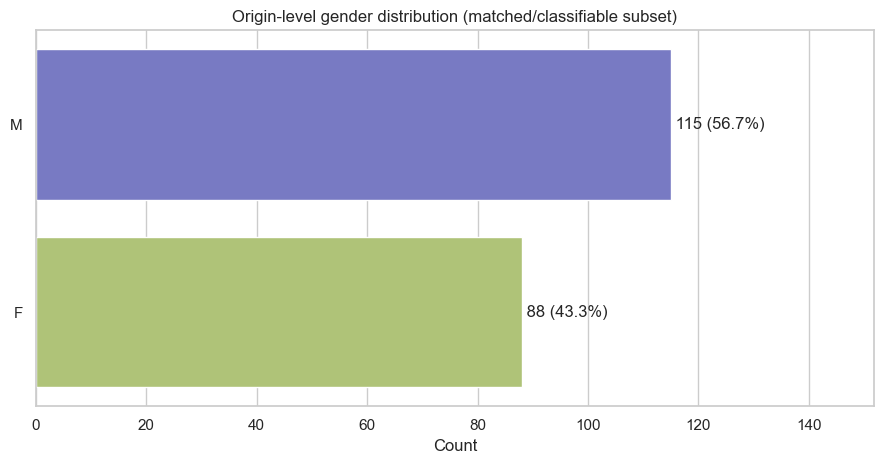

,count,percent
gender,,
M,115,56.650246
F,88,43.349754


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/03_patch_gender_count_percent.png


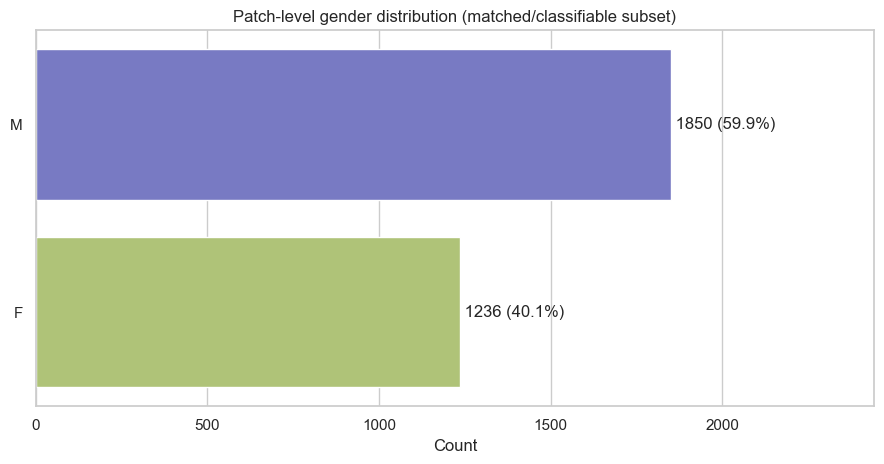

,count,percent
gender,,
M,1850,59.948153
F,1236,40.051847


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/03_origin_skin_color_count_percent.png


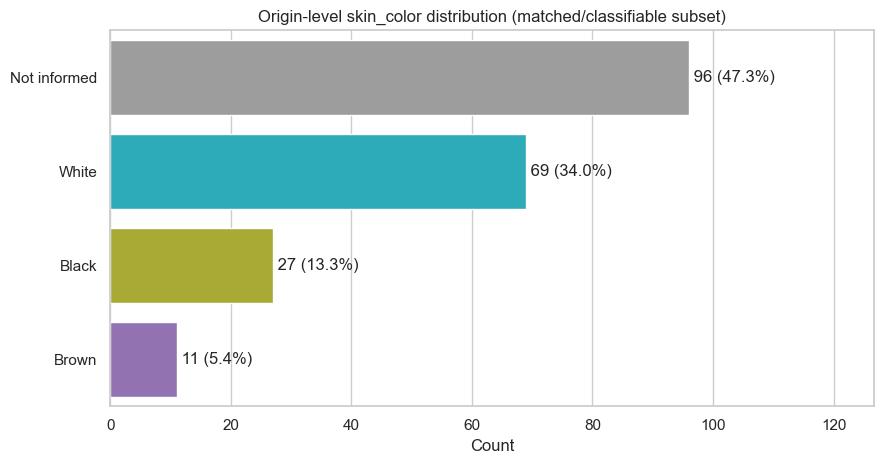

,count,percent
skin_color,,
Not informed,96,47.290640
White,69,33.990148
Black,27,13.300493
Brown,11,5.418719


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/03_patch_skin_color_count_percent.png


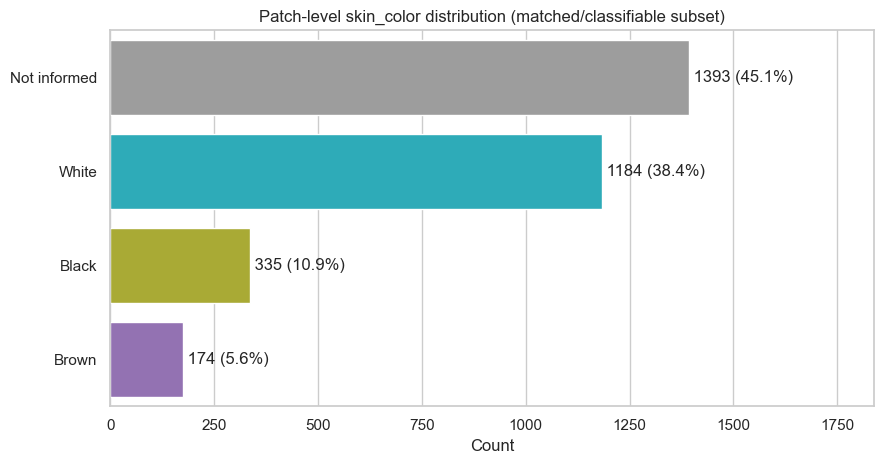

,count,percent
skin_color,,
Not informed,1393,45.139339
White,1184,38.366818
Black,335,10.855476
Brown,174,5.638367


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/03_origin_age_group_label_count_percent.png


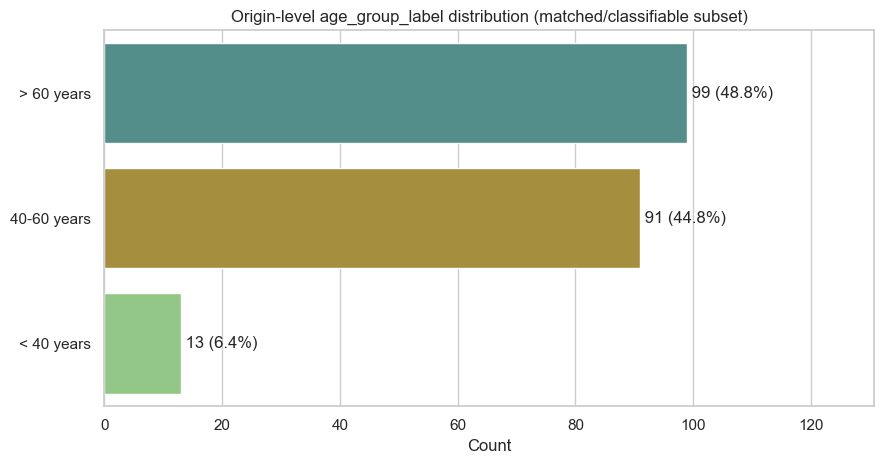

,count,percent
age_group_label,,
> 60 years,99,48.768473
40-60 years,91,44.827586
< 40 years,13,6.403941


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/03_patch_age_group_label_count_percent.png


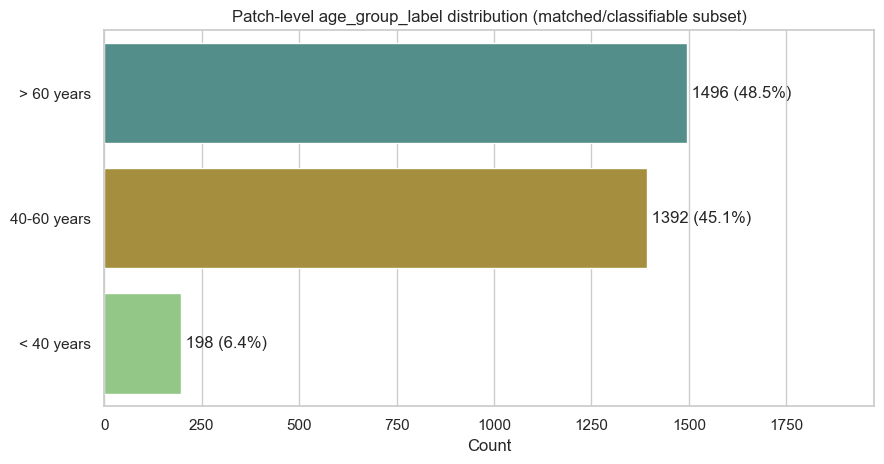

,count,percent
age_group_label,,
> 60 years,1496,48.476993
40-60 years,1392,45.106935
< 40 years,198,6.416073


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/03_origin_localization_count_percent.png


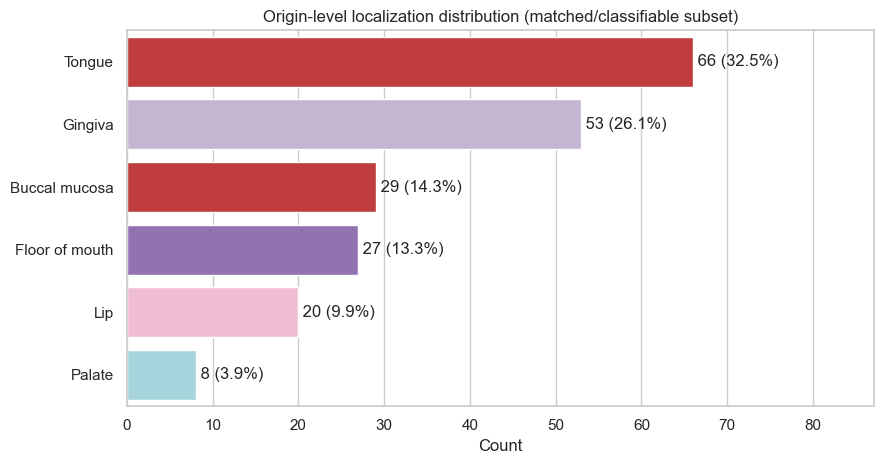

,count,percent
localization,,
Tongue,66,32.512315
Gingiva,53,26.108374
Buccal mucosa,29,14.285714
Floor of mouth,27,13.300493
Lip,20,9.852217
Palate,8,3.940887


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/03_patch_localization_count_percent.png


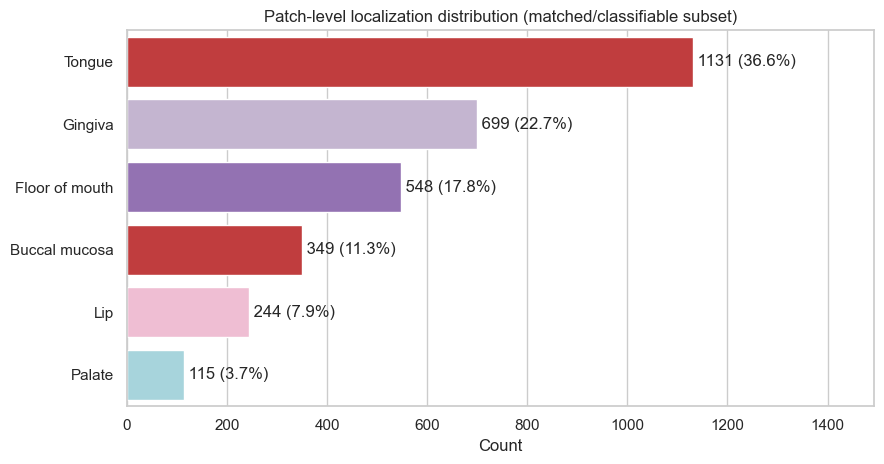

,count,percent
localization,,
Tongue,1131,36.649384
Gingiva,699,22.650680
Floor of mouth,548,17.757615
Buccal mucosa,349,11.309138
Lip,244,7.906675
Palate,115,3.726507


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/03_origin_tobacco_use_count_percent.png


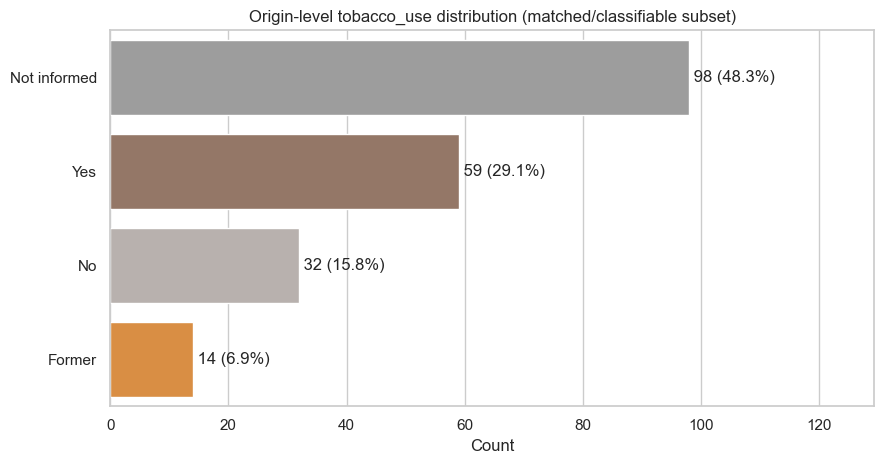

,count,percent
tobacco_use,,
Not informed,98,48.275862
Yes,59,29.064039
No,32,15.763547
Former,14,6.896552


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/03_patch_tobacco_use_count_percent.png


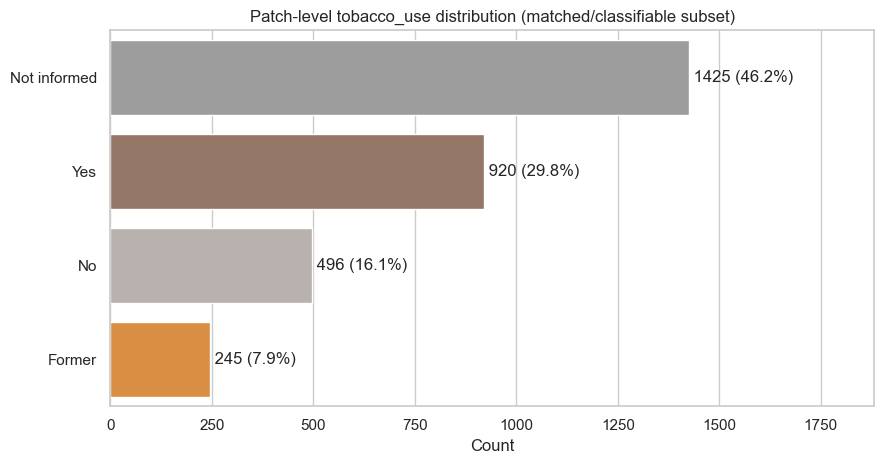

,count,percent
tobacco_use,,
Not informed,1425,46.176280
Yes,920,29.812054
No,496,16.072586
Former,245,7.939080


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/03_origin_alcohol_consumption_count_percent.png


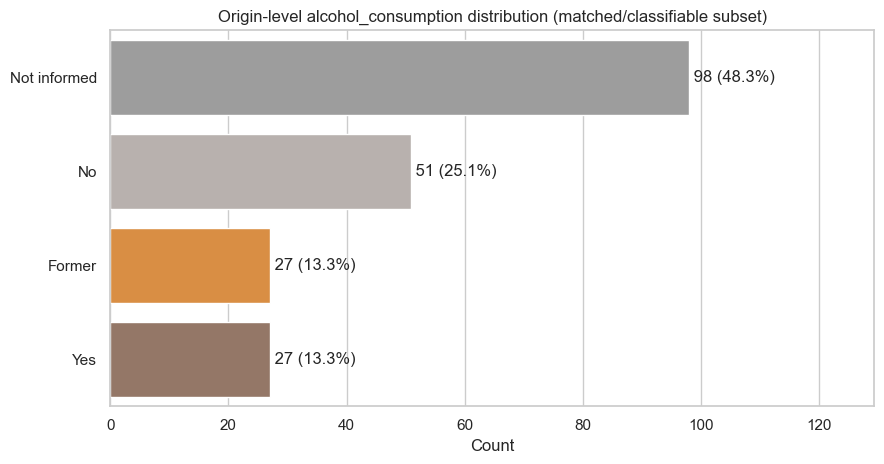

,count,percent
alcohol_consumption,,
Not informed,98,48.275862
No,51,25.123153
Former,27,13.300493
Yes,27,13.300493


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/03_patch_alcohol_consumption_count_percent.png


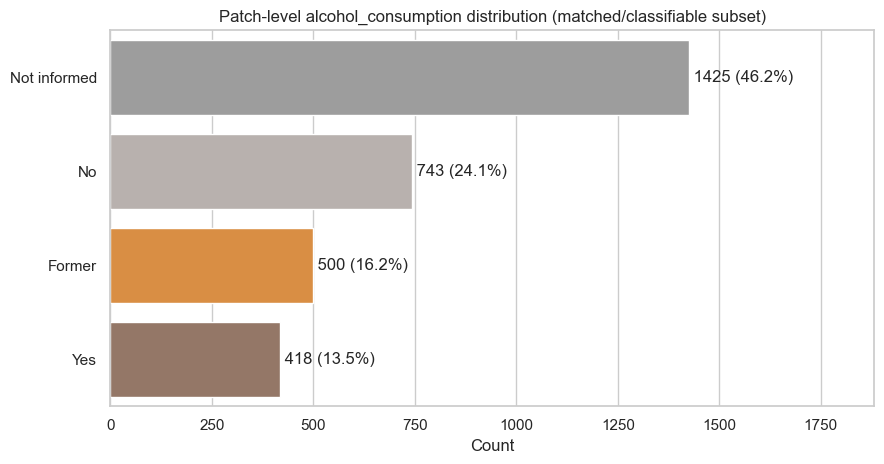

,count,percent
alcohol_consumption,,
Not informed,1425,46.176280
No,743,24.076474
Former,500,16.202203
Yes,418,13.545042


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/03_origin_sun_exposure_count_percent.png


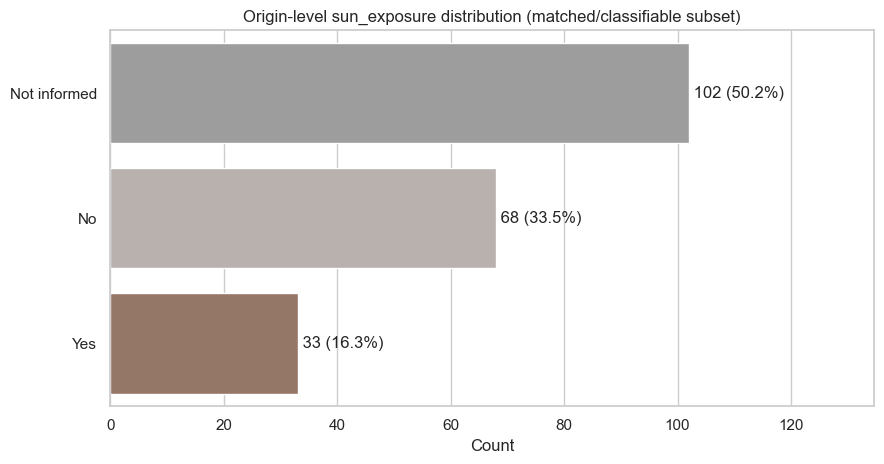

,count,percent
sun_exposure,,
Not informed,102,50.246305
No,68,33.497537
Yes,33,16.256158


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/03_patch_sun_exposure_count_percent.png


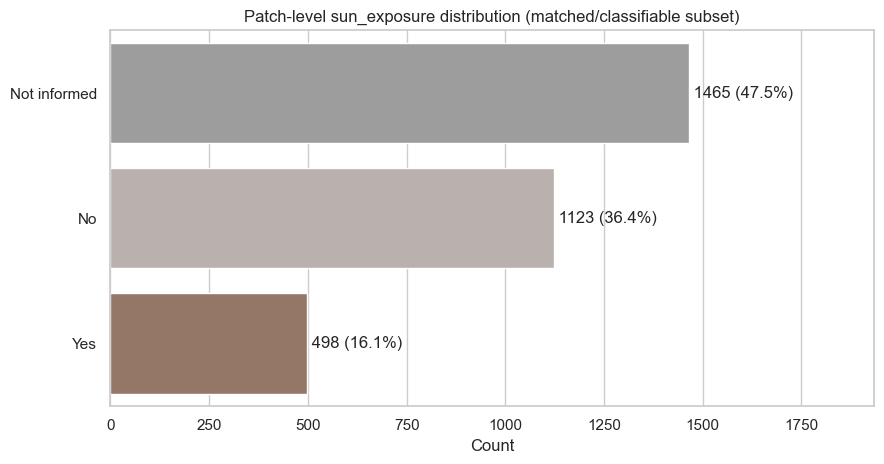

,count,percent
sun_exposure,,
Not informed,1465,47.472456
No,1123,36.390149
Yes,498,16.137395


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/03_origin_dysplasia_severity_count_percent.png


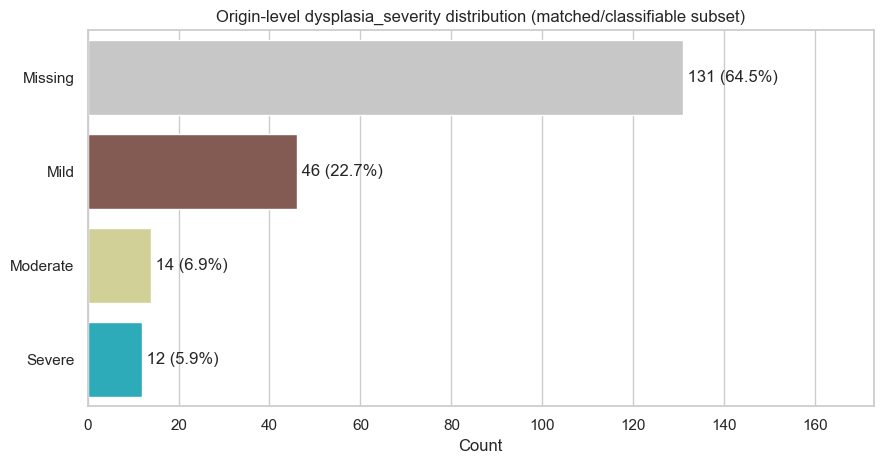

,count,percent
dysplasia_severity,,
Missing,131,64.532020
Mild,46,22.660099
Moderate,14,6.896552
Severe,12,5.911330


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/03_patch_dysplasia_severity_count_percent.png


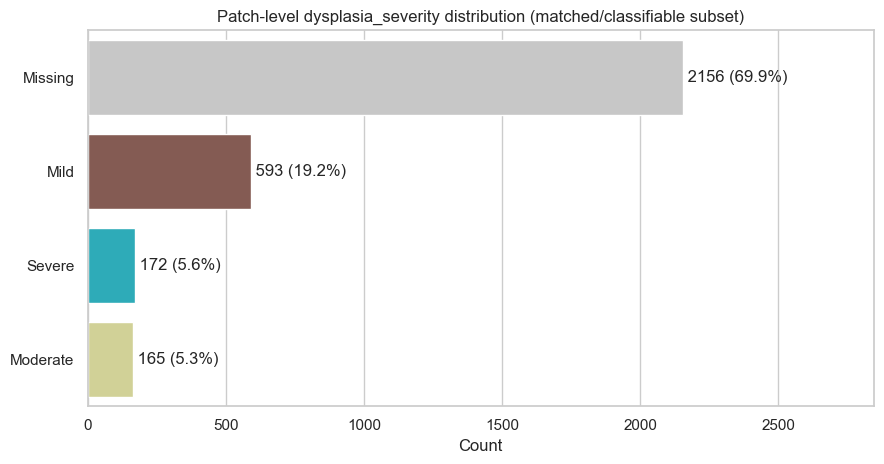

,count,percent
dysplasia_severity,,
Missing,2156,69.863901
Mild,593,19.215813
Severe,172,5.573558
Moderate,165,5.346727


In [33]:
categorical_vars = [
    "gender",
    "skin_color",
    "age_group_label",
    "localization",
    "tobacco_use",
    "alcohol_consumption",
    "sun_exposure",
    "dysplasia_severity",
]

for col in categorical_vars:
    if col in matched_origin_df.columns:
        plot_count_percent_distribution(
            matched_origin_df,
            col,
            f"Origin-level {col} distribution (matched/classifiable subset)",
            f"03_origin_{col}_count_percent.png",
        )
    if col in patch_df.columns:
        plot_count_percent_distribution(
            patch_df,
            col,
            f"Patch-level {col} distribution (matched/classifiable subset)",
            f"03_patch_{col}_count_percent.png",
        )


## Missingness and `Not informed`

The NDB-UFES metadata uses `Not informed` in multiple clinical/demographic fields. For public documentation, this should be reported explicitly rather than silently treated as ordinary category balance.

High `Not informed` rates are a warning sign for stratification. A variable that is almost half unknown is not a trustworthy stratification variable: the unknown group may mix several real subgroups in arbitrary proportions, and using it can create artificial balance rather than meaningful balance. These fields can remain in the factsheet and descriptive notebook, but the fold-construction script should not automatically stratify by them.


,variable,missing_na,not_informed,combined_count,combined_percent
8,dysplasia_severity,131,0,131,64.532020
7,sun_exposure,0,102,102,50.246305
5,tobacco_use,0,98,98,48.275862
6,alcohol_consumption,0,98,98,48.275862
1,skin_color,0,96,96,47.290640
0,gender,0,0,0,0.000000
2,age_group_label,0,0,0,0.000000
3,localization,0,0,0,0.000000
4,larger_size,0,0,0,0.000000
9,TaskII,0,0,0,0.000000


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/04a_origin_missing_not_informed_rates.png


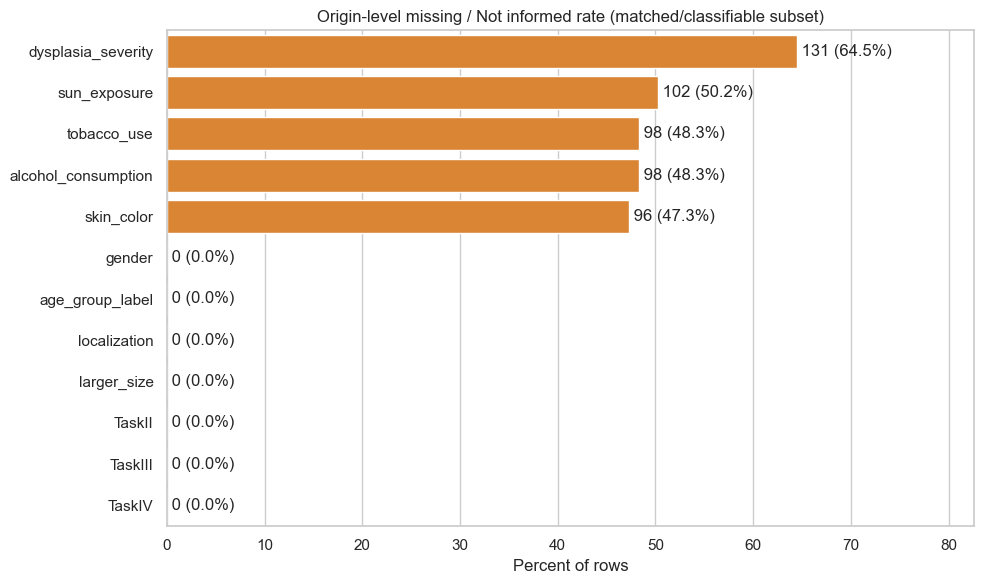

,variable,missing_na,not_informed,combined_count,combined_percent
8,dysplasia_severity,2156,0,2156,69.863901
7,sun_exposure,0,1465,1465,47.472456
5,tobacco_use,0,1425,1425,46.176280
6,alcohol_consumption,0,1425,1425,46.176280
1,skin_color,0,1393,1393,45.139339
0,gender,0,0,0,0.000000
2,age_group_label,0,0,0,0.000000
3,localization,0,0,0,0.000000
4,larger_size,0,0,0,0.000000
9,TaskII,0,0,0,0.000000


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/04b_patch_missing_not_informed_rates.png


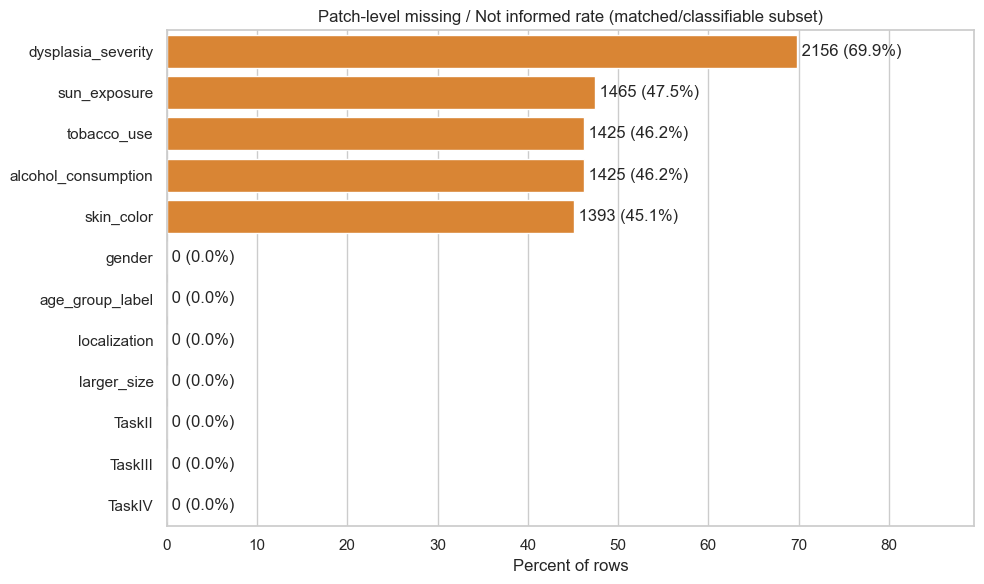

Variables with >=40% missing/Not informed at patch level; keep descriptive, avoid automatic stratification:


,variable,combined_count,combined_percent
8,dysplasia_severity,2156,69.863901
7,sun_exposure,1465,47.472456
5,tobacco_use,1425,46.176280
6,alcohol_consumption,1425,46.176280
1,skin_color,1393,45.139339


In [34]:
audit_vars = [
    "gender",
    "skin_color",
    "age_group_label",
    "localization",
    "larger_size",
    "tobacco_use",
    "alcohol_consumption",
    "sun_exposure",
    "dysplasia_severity",
    "TaskII",
    "TaskIII",
    "TaskIV",
]


def missingness_table(df, variables):
    rows = []
    for col in variables:
        if col not in df.columns:
            continue
        s = df[col]
        missing = s.isna().sum()
        not_informed = (s.astype(str).str.lower() == "not informed").sum()
        rows.append({
            "variable": col,
            "missing_na": int(missing),
            "not_informed": int(not_informed),
            "combined_count": int(missing + not_informed),
            "combined_percent": 100 * (missing + not_informed) / len(df),
        })
    return pd.DataFrame(rows).sort_values("combined_percent", ascending=False)


def plot_missingness(df, variables, title, filename):
    miss = missingness_table(df, variables)
    display(miss)
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=miss, x="combined_percent", y="variable", color="#F58518", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Percent of rows")
    ax.set_ylabel("")
    ax.set_xlim(0, max(1, miss["combined_percent"].max() * 1.28))
    for i, row in enumerate(miss.itertuples(index=False)):
        ax.text(row.combined_percent, i, f" {row.combined_count} ({row.combined_percent:.1f}%)", va="center")
    fig.tight_layout()
    save_fig(filename, fig)
    plt.show()
    return miss

origin_missing_df = plot_missingness(
    matched_origin_df,
    audit_vars,
    "Origin-level missing / Not informed rate (matched/classifiable subset)",
    "04a_origin_missing_not_informed_rates.png",
)

patch_missing_df = plot_missingness(
    patch_df,
    audit_vars,
    "Patch-level missing / Not informed rate (matched/classifiable subset)",
    "04b_patch_missing_not_informed_rates.png",
)

high_missing_patch = patch_missing_df[patch_missing_df["combined_percent"] >= 40]
if not high_missing_patch.empty:
    print("Variables with >=40% missing/Not informed at patch level; keep descriptive, avoid automatic stratification:")
    display(high_missing_patch[["variable", "combined_count", "combined_percent"]])


## Age Skew and Diagnosis Relationships

Age groups have semantic order, so all age plots use `< 40 years`, `40-60 years`, `> 60 years`. The diagnosis-by-age heatmaps are shown two ways:

- row percentage: within each diagnosis, how much comes from each age group;
- column percentage: within each age group, how much belongs to each diagnosis.

This helps separate questions like “61% of OSCC patches are from >60” from “among >60 patches, what percentage are OSCC?”


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/05a_origin_age_group_count_percent.png


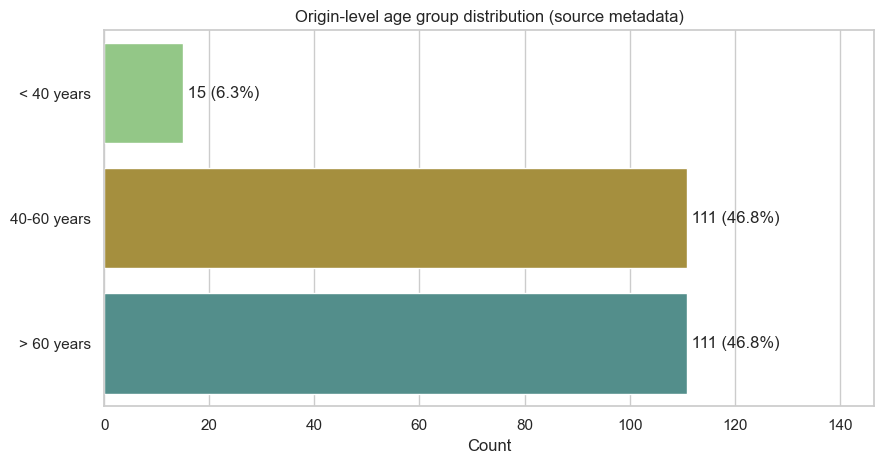

,count,percent
age_group_label,,
< 40 years,15,6.329114
40-60 years,111,46.835443
> 60 years,111,46.835443


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/05b_patch_age_group_count_percent.png


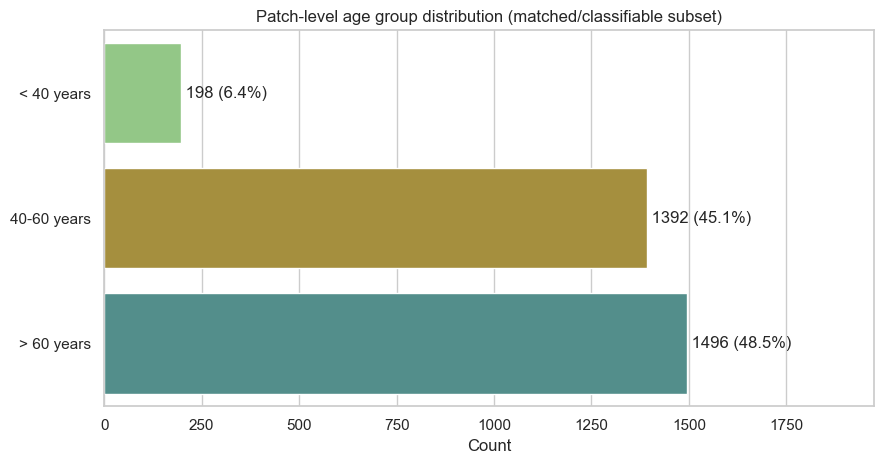

,count,percent
age_group_label,,
< 40 years,198,6.416073
40-60 years,1392,45.106935
> 60 years,1496,48.476993


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/06a_diagnosis_by_age_group_row_percent.png


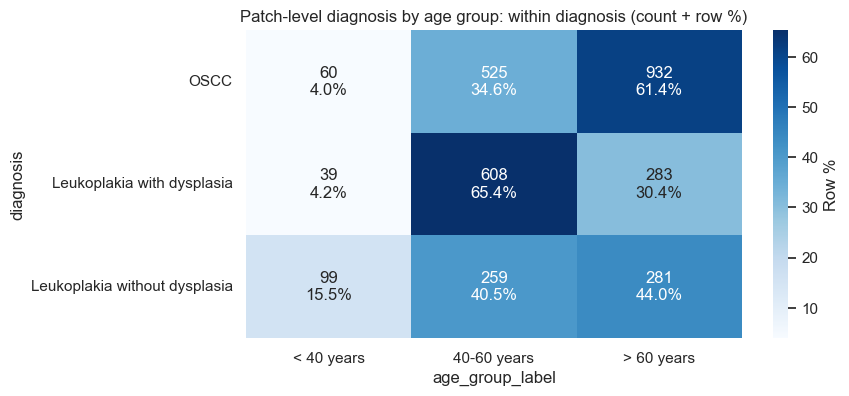

age_group_label,< 40 years,40-60 years,> 60 years
diagnosis,,,
OSCC,60,525,932
Leukoplakia with dysplasia,39,608,283
Leukoplakia without dysplasia,99,259,281


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/06b_diagnosis_by_age_group_column_percent.png


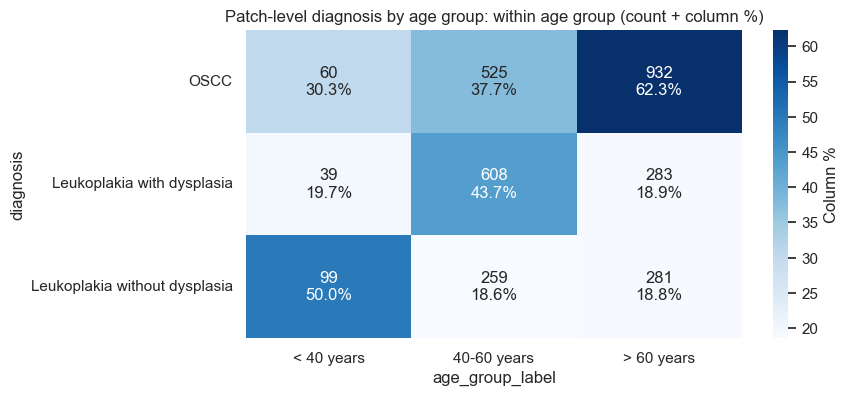

age_group_label,< 40 years,40-60 years,> 60 years
diagnosis,,,
OSCC,60,525,932
Leukoplakia with dysplasia,39,608,283
Leukoplakia without dysplasia,99,259,281


In [35]:
age_order = ["< 40 years", "40-60 years", "> 60 years"]

plot_count_percent_distribution(
    origin_df,
    "age_group_label",
    "Origin-level age group distribution (source metadata)",
    "05a_origin_age_group_count_percent.png",
    order=age_order,
)

plot_count_percent_distribution(
    patch_df,
    "age_group_label",
    "Patch-level age group distribution (matched/classifiable subset)",
    "05b_patch_age_group_count_percent.png",
    order=age_order,
)

age_diag_row_counts, age_diag_row_pct = plot_crosstab_heatmap(
    patch_df,
    "diagnosis",
    "age_group_label",
    "06a_diagnosis_by_age_group_row_percent.png",
    title="Patch-level diagnosis by age group: within diagnosis (count + row %)",
    normalize="row",
    row_order=diagnosis_order,
    col_order=age_order,
)
display(age_diag_row_counts)

age_diag_col_counts, age_diag_col_pct = plot_crosstab_heatmap(
    patch_df,
    "diagnosis",
    "age_group_label",
    "06b_diagnosis_by_age_group_column_percent.png",
    title="Patch-level diagnosis by age group: within age group (count + column %)",
    normalize="column",
    row_order=diagnosis_order,
    col_order=age_order,
)
display(age_diag_col_counts)


## Clinical Variables by Diagnosis

These heatmaps make obvious imbalances visible. They are descriptive and should not be interpreted as causal effects or as automatic stratification instructions. Origin-level heatmaps are shown before patch-level heatmaps for each variable.


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/07_origin_diagnosis_by_gender_row_percent.png


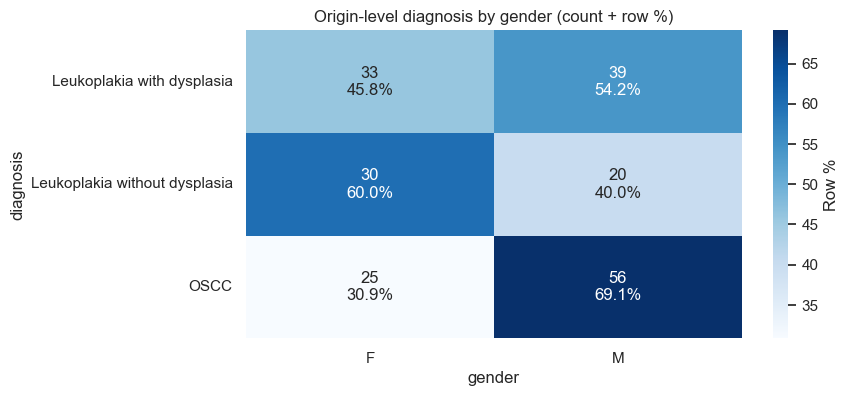

gender,F,M
diagnosis,,
Leukoplakia with dysplasia,33,39
Leukoplakia without dysplasia,30,20
OSCC,25,56


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/07_patch_diagnosis_by_gender_row_percent.png


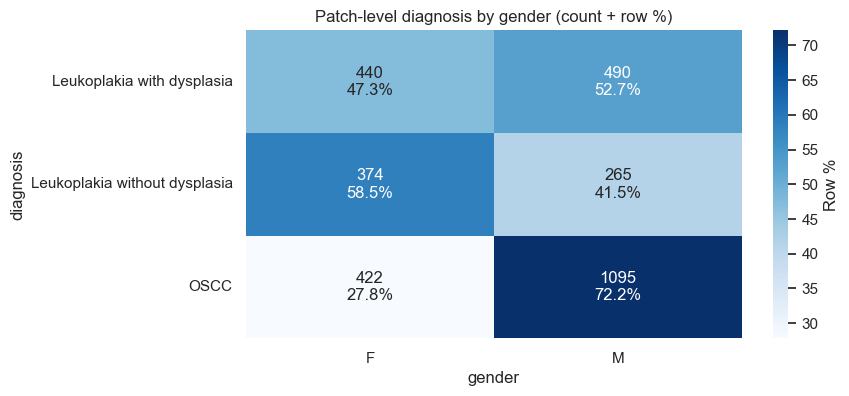

gender,F,M
diagnosis,,
Leukoplakia with dysplasia,440,490
Leukoplakia without dysplasia,374,265
OSCC,422,1095


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/07_origin_diagnosis_by_skin_color_row_percent.png


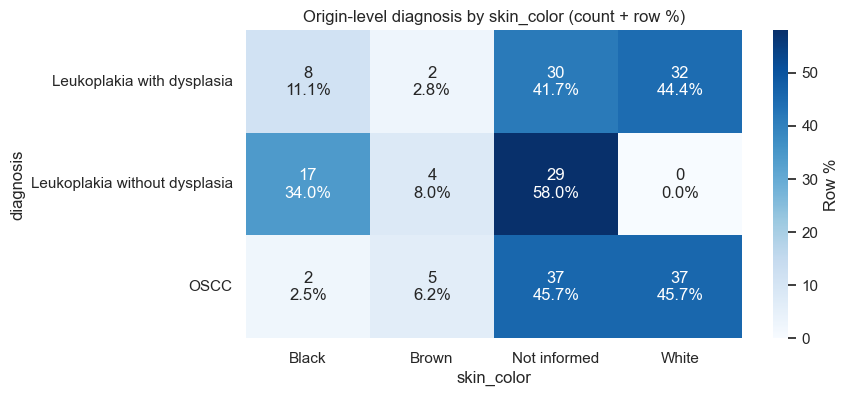

skin_color,Black,Brown,Not informed,White
diagnosis,,,,
Leukoplakia with dysplasia,8,2,30,32
Leukoplakia without dysplasia,17,4,29,0
OSCC,2,5,37,37


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/07_patch_diagnosis_by_skin_color_row_percent.png


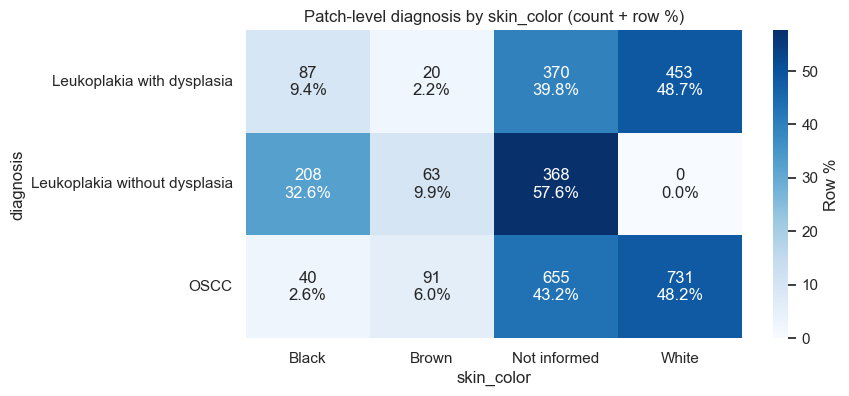

skin_color,Black,Brown,Not informed,White
diagnosis,,,,
Leukoplakia with dysplasia,87,20,370,453
Leukoplakia without dysplasia,208,63,368,0
OSCC,40,91,655,731


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/07_origin_diagnosis_by_tobacco_use_row_percent.png


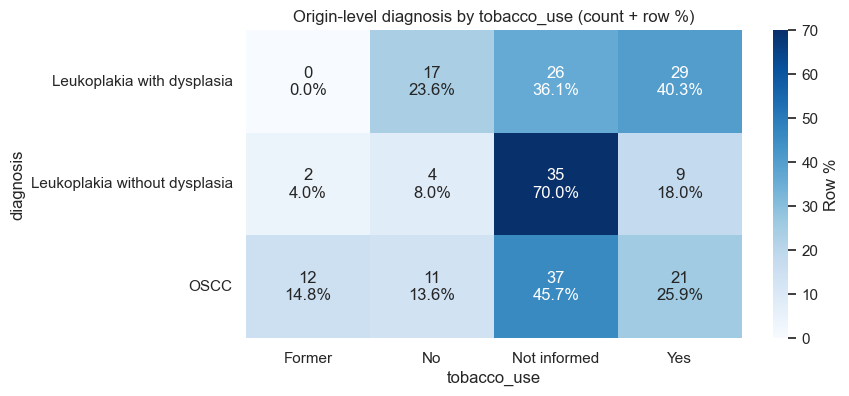

tobacco_use,Former,No,Not informed,Yes
diagnosis,,,,
Leukoplakia with dysplasia,0,17,26,29
Leukoplakia without dysplasia,2,4,35,9
OSCC,12,11,37,21


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/07_patch_diagnosis_by_tobacco_use_row_percent.png


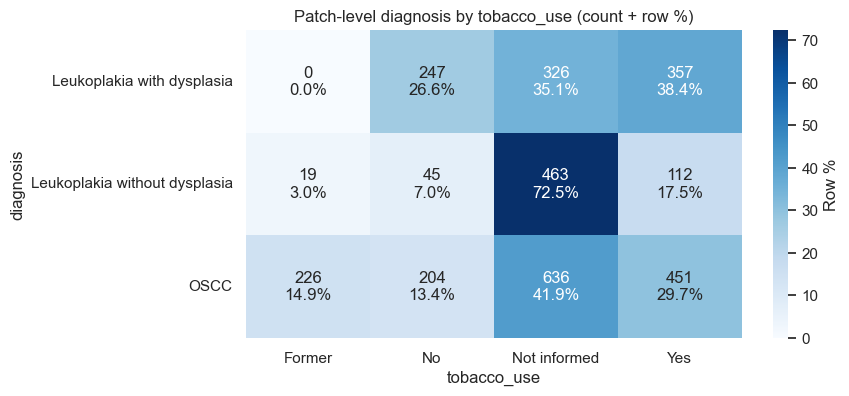

tobacco_use,Former,No,Not informed,Yes
diagnosis,,,,
Leukoplakia with dysplasia,0,247,326,357
Leukoplakia without dysplasia,19,45,463,112
OSCC,226,204,636,451


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/07_origin_diagnosis_by_alcohol_consumption_row_percent.png


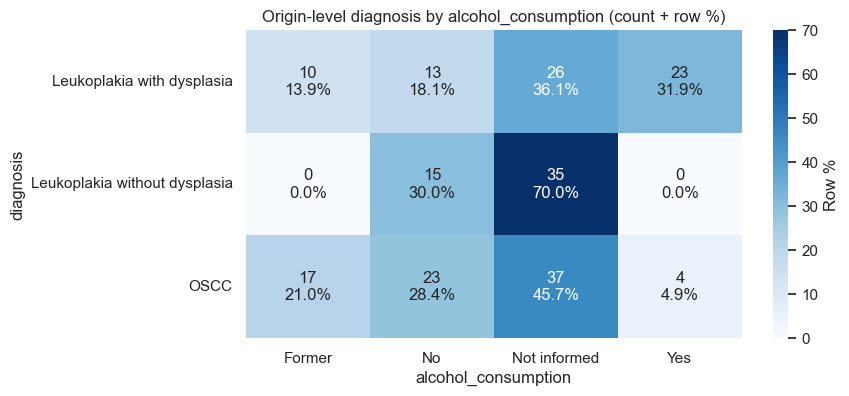

alcohol_consumption,Former,No,Not informed,Yes
diagnosis,,,,
Leukoplakia with dysplasia,10,13,26,23
Leukoplakia without dysplasia,0,15,35,0
OSCC,17,23,37,4


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/07_patch_diagnosis_by_alcohol_consumption_row_percent.png


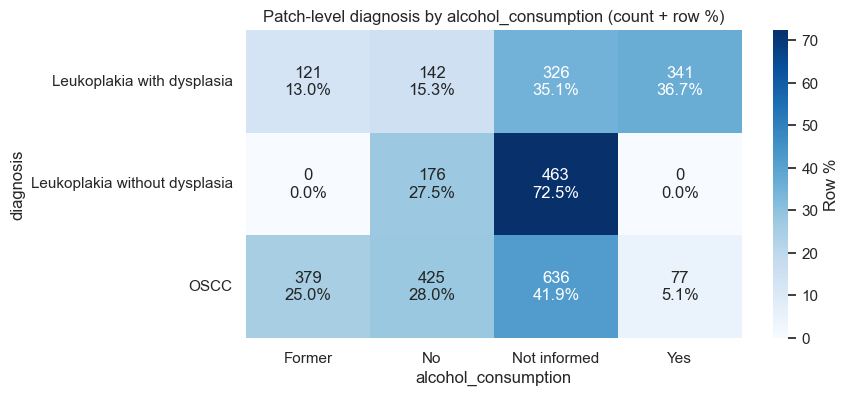

alcohol_consumption,Former,No,Not informed,Yes
diagnosis,,,,
Leukoplakia with dysplasia,121,142,326,341
Leukoplakia without dysplasia,0,176,463,0
OSCC,379,425,636,77


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/07_origin_diagnosis_by_sun_exposure_row_percent.png


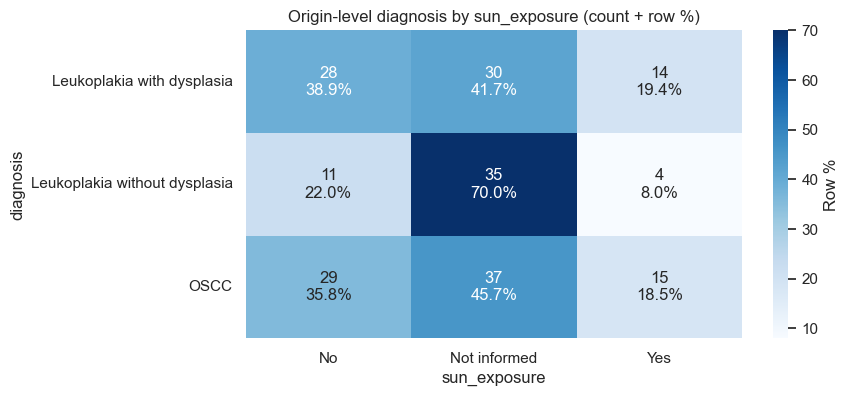

sun_exposure,No,Not informed,Yes
diagnosis,,,
Leukoplakia with dysplasia,28,30,14
Leukoplakia without dysplasia,11,35,4
OSCC,29,37,15


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/07_patch_diagnosis_by_sun_exposure_row_percent.png


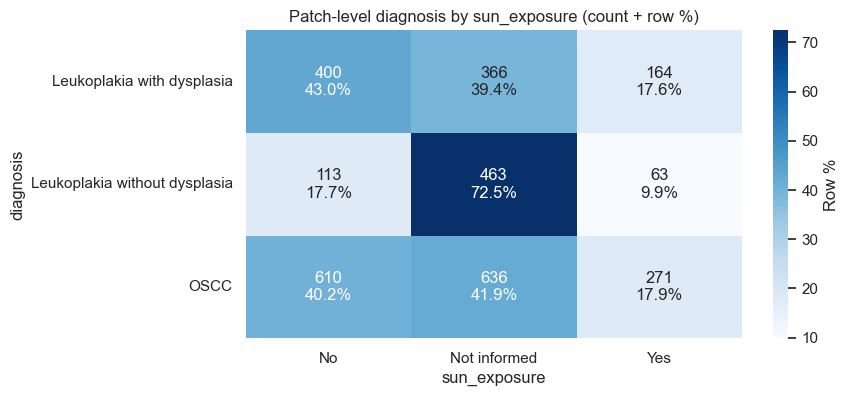

sun_exposure,No,Not informed,Yes
diagnosis,,,
Leukoplakia with dysplasia,400,366,164
Leukoplakia without dysplasia,113,463,63
OSCC,610,636,271


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/07_origin_diagnosis_by_localization_row_percent.png


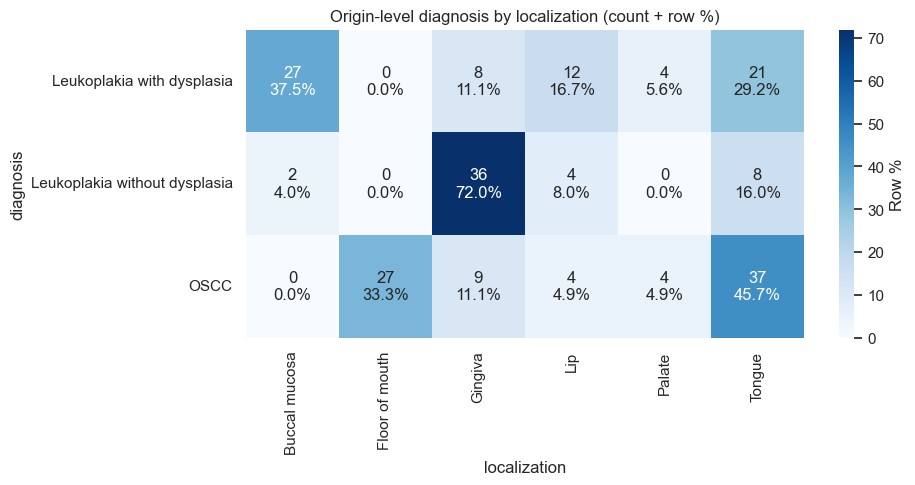

localization,Buccal mucosa,Floor of mouth,Gingiva,Lip,Palate,Tongue
diagnosis,,,,,,
Leukoplakia with dysplasia,27,0,8,12,4,21
Leukoplakia without dysplasia,2,0,36,4,0,8
OSCC,0,27,9,4,4,37


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/07_patch_diagnosis_by_localization_row_percent.png


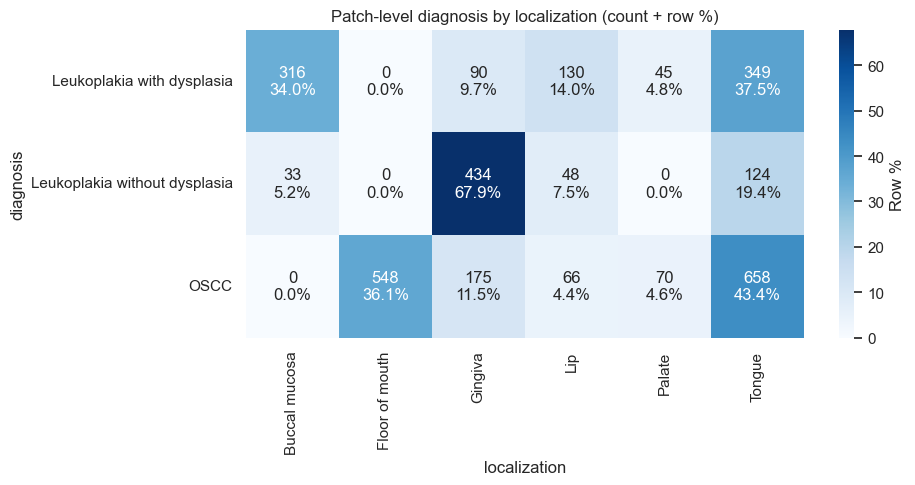

localization,Buccal mucosa,Floor of mouth,Gingiva,Lip,Palate,Tongue
diagnosis,,,,,,
Leukoplakia with dysplasia,316,0,90,130,45,349
Leukoplakia without dysplasia,33,0,434,48,0,124
OSCC,0,548,175,66,70,658


In [36]:
for col in ["gender", "skin_color", "tobacco_use", "alcohol_consumption", "sun_exposure", "localization"]:
    if col in matched_origin_df.columns:
        origin_tab, origin_pct = plot_crosstab_heatmap(
            matched_origin_df,
            "diagnosis",
            col,
            f"07_origin_diagnosis_by_{col}_row_percent.png",
            title=f"Origin-level diagnosis by {col} (count + row %)",
        )
        display(origin_tab)
    if col in patch_df.columns:
        patch_tab, patch_pct = plot_crosstab_heatmap(
            patch_df,
            "diagnosis",
            col,
            f"07_patch_diagnosis_by_{col}_row_percent.png",
            title=f"Patch-level diagnosis by {col} (count + row %)",
        )
        display(patch_tab)


## Variable Association Heatmap

For categorical variables, this notebook uses Cramer's V. Values closer to 1 indicate stronger association; values near 0 indicate weak association. This is useful for finding variables that may be highly related or redundant.

saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/08_categorical_association_cramers_v.png


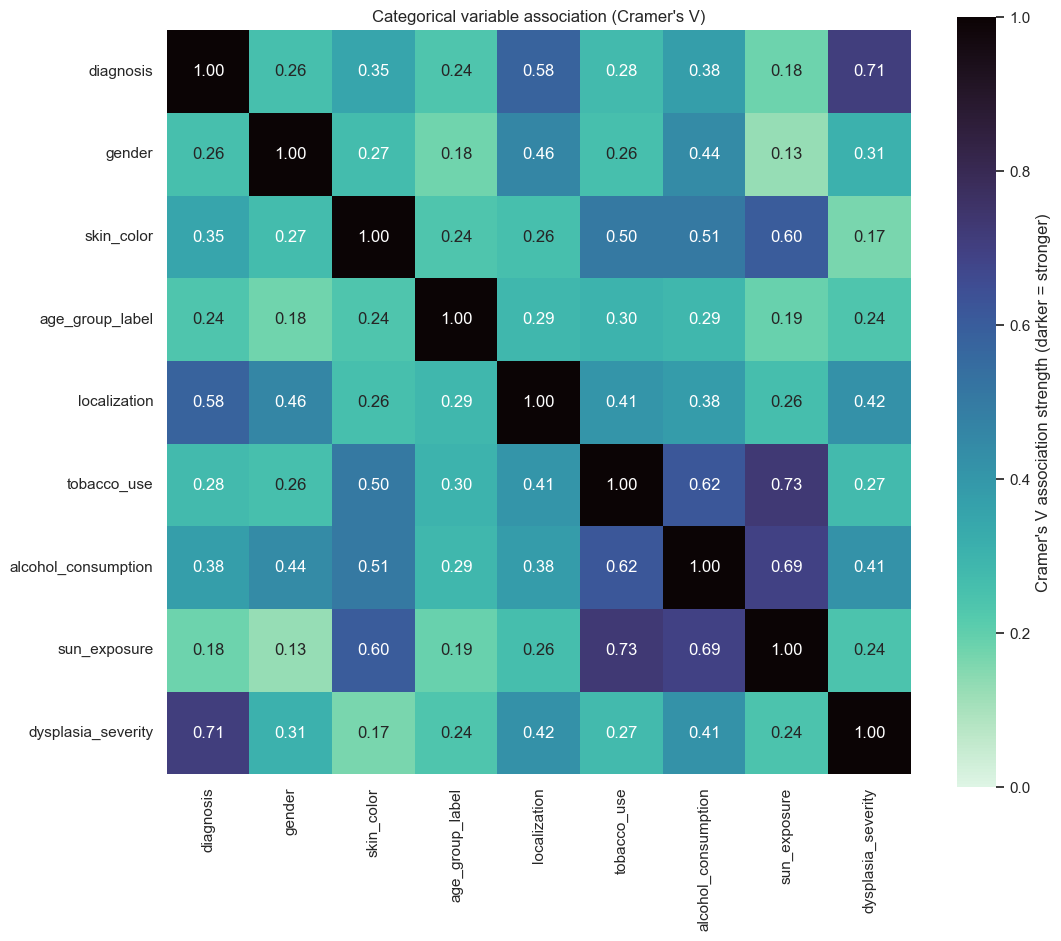

,var_a,var_b,cramers_v
31,tobacco_use,sun_exposure,0.726844
7,diagnosis,dysplasia_severity,0.707107
33,alcohol_consumption,sun_exposure,0.692542
30,tobacco_use,alcohol_consumption,0.620596
19,skin_color,sun_exposure,0.603048
3,diagnosis,localization,0.580640
18,skin_color,alcohol_consumption,0.505894
17,skin_color,tobacco_use,0.504953
10,gender,localization,0.459038
12,gender,alcohol_consumption,0.443532


In [37]:
assoc_vars = [
    "diagnosis",
    "gender",
    "skin_color",
    "age_group_label",
    "localization",
    "tobacco_use",
    "alcohol_consumption",
    "sun_exposure",
    "dysplasia_severity",
]
assoc_vars = [c for c in assoc_vars if c in patch_df.columns]

assoc = pd.DataFrame(index=assoc_vars, columns=assoc_vars, dtype=float)
for a in assoc_vars:
    for b in assoc_vars:
        assoc.loc[a, b] = 1.0 if a == b else cramers_v(patch_df[a], patch_df[b])

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    assoc,
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".2f",
    cmap="mako_r",
    square=True,
    cbar_kws={"label": "Cramer's V association strength (darker = stronger)"},
    ax=ax,
)
ax.set_title("Categorical variable association (Cramer's V)")
save_fig("08_categorical_association_cramers_v.png", fig)
plt.show()

pairs = []
for i, a in enumerate(assoc_vars):
    for b in assoc_vars[i + 1:]:
        pairs.append({"var_a": a, "var_b": b, "cramers_v": assoc.loc[a, b]})
pairs_df = pd.DataFrame(pairs).sort_values("cramers_v", ascending=False)
display(pairs_df.head(20))
pairs_df.to_csv(OUT_DIR / "categorical_association_cramers_v.csv", index=False)

## Lesion Size

The source paper reports lesion size in centimeters. Coordinate-derived ROI fields are deferred: patch-origin associations and coordinates need to be rerun before plotting patch coverage on origin images. A future to-do is to draw example origin images with patch rectangles after the coordinate association is corrected.


,count,mean,std,min,25%,50%,75%,max
larger_size,3086.0,1.704634,1.420428,0.0,0.4,1.5,3.0,5.0


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/09_larger_size_histogram_count_percent.png


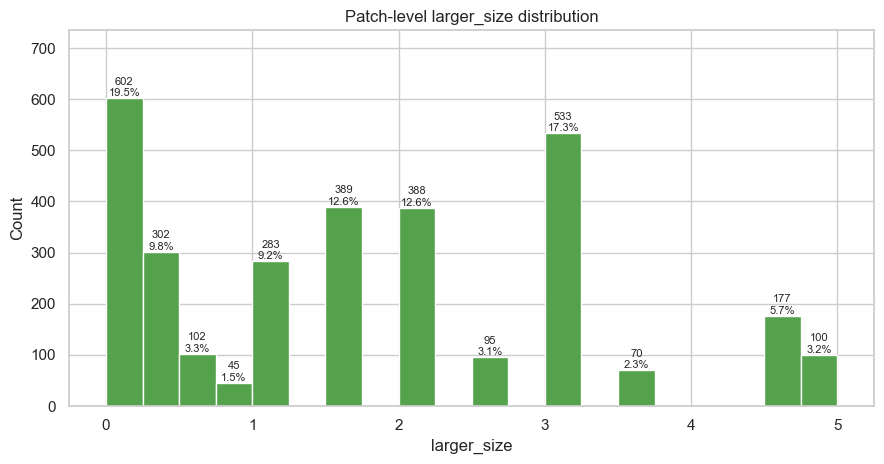

,count,mean,std,min,25%,50%,75%,max
larger_size,3086.0,1.704634,1.420428,0.0,0.4,1.5,3.0,5.0


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/10_lesion_size_by_diagnosis.png


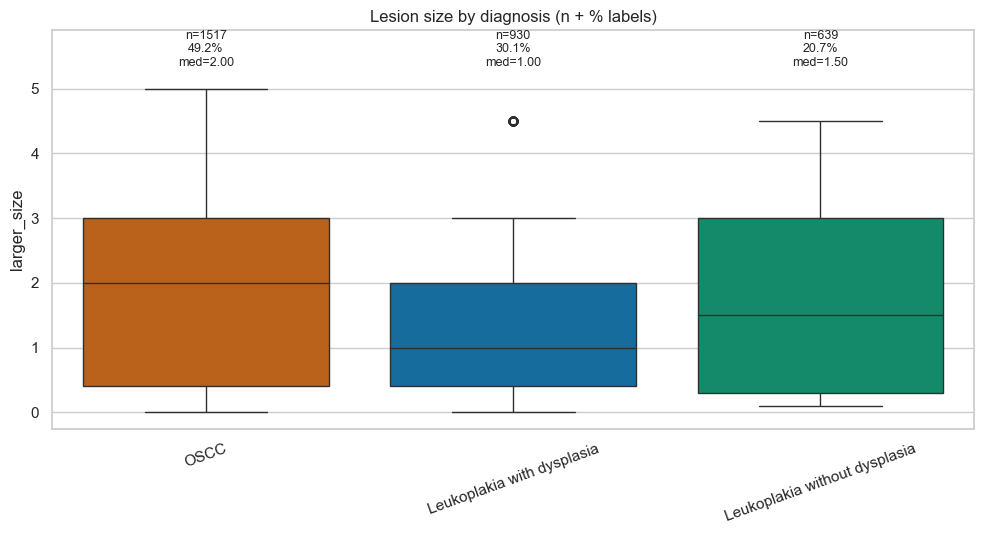

,count,mean,std,min,25%,50%,75%,max
diagnosis,,,,,,,,
Leukoplakia with dysplasia,930.0,1.345054,1.280121,0.0,0.4,1.0,2.0,4.5
Leukoplakia without dysplasia,639.0,1.671987,1.520100,0.1,0.3,1.5,3.0,4.5
OSCC,1517.0,1.938827,1.412259,0.0,0.4,2.0,3.0,5.0


TODO after final audit: recompute coordinate associations and add an origin-image patch coverage example.


In [38]:
numeric_cols = [c for c in ["larger_size"] if c in patch_df.columns]
for col in numeric_cols:
    patch_df[col] = pd.to_numeric(patch_df[col], errors="coerce")

display(patch_df[numeric_cols].describe().T)

for col in numeric_cols:
    plot_numeric_histogram(
        patch_df,
        col,
        f"Patch-level {col} distribution",
        f"09_{col}_histogram_count_percent.png",
        bins=20,
        color="#54A24B",
    )

if "larger_size" in patch_df.columns:
    lesion_summary = plot_boxplot_with_counts(
        patch_df,
        "diagnosis",
        "larger_size",
        "Lesion size by diagnosis (n + % labels)",
        "10_lesion_size_by_diagnosis.png",
        order=diagnosis_order,
    )
    display(lesion_summary)

print("TODO after final audit: recompute coordinate associations and add an origin-image patch coverage example.")


## Provisional Fold Characteristics

This section is intentionally provisional. It should be rerun after Phase 2 morphology selection is accepted and Phase 3 folds are regenerated or explicitly validated. If fold files are absent, the cell leaves a placeholder.

Loaded provisional patch folds: (3086, 7)


,patch_id,origin_id,image_name,image_path,class,morph_cluster,fold
0,0_0,0,p0321,data/ndb_ufes/patch/images/p0321.png,OSCC,2,5
1,0_1,0,p0322,data/ndb_ufes/patch/images/p0322.png,OSCC,2,5
2,0_2,0,p0323,data/ndb_ufes/patch/images/p0323.png,OSCC,2,5
3,0_3,0,p0324,data/ndb_ufes/patch/images/p0324.png,OSCC,2,5
4,0_4,0,p0325,data/ndb_ufes/patch/images/p0325.png,OSCC,2,5


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/11a_provisional_patch_count_by_fold.png


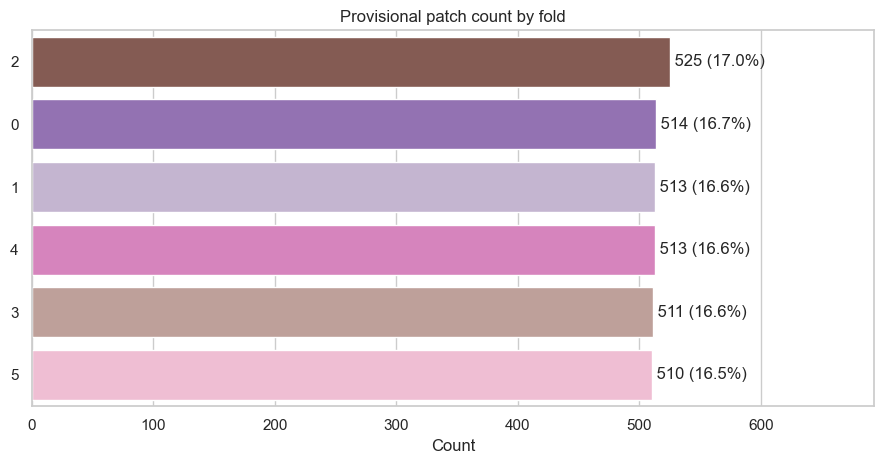

,count,percent
fold,,
2,525,17.012314
0,514,16.655865
1,513,16.623461
4,513,16.623461
3,511,16.558652
5,510,16.526248


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/11b_provisional_class_by_fold_count_percent.png


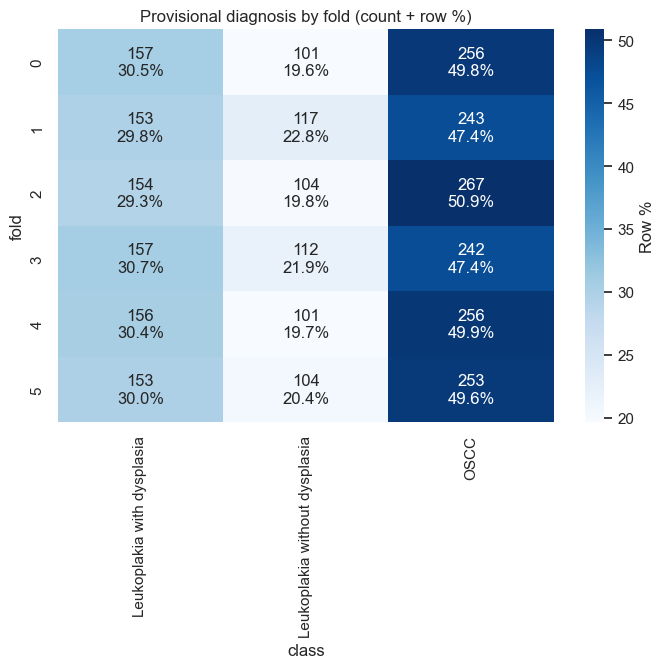

class,Leukoplakia with dysplasia,Leukoplakia without dysplasia,OSCC
fold,,,
0,157,101,256
1,153,117,243
2,154,104,267
3,157,112,242
4,156,101,256
5,153,104,253


saved /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/dataset_statistics/11c_provisional_morph_cluster_by_fold_count_percent.png


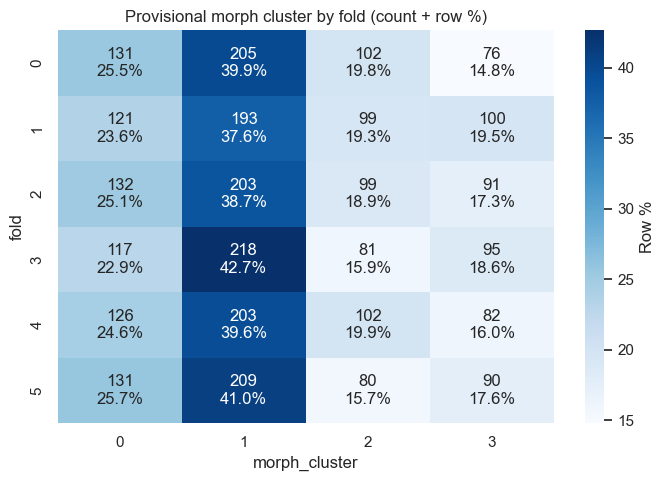

morph_cluster,0,1,2,3
fold,,,,
0,131,205,102,76
1,121,193,99,100
2,132,203,99,91
3,117,218,81,95
4,126,203,102,82
5,131,209,80,90


,fold,n_patches,n_origins
0,0,514,36
1,1,513,31
2,2,525,36
3,3,511,34
4,4,513,32
5,5,510,34


In [39]:
if PROVISIONAL_PATCH_FOLDS.exists():
    folds = pd.read_csv(PROVISIONAL_PATCH_FOLDS)
    print("Loaded provisional patch folds:", folds.shape)
    display(folds.head())

    plot_count_percent_distribution(
        folds,
        "fold",
        "Provisional patch count by fold",
        "11a_provisional_patch_count_by_fold.png",
    )

    if "class" in folds.columns:
        fold_class_counts, fold_class_pct = plot_crosstab_heatmap(
            folds,
            "fold",
            "class",
            "11b_provisional_class_by_fold_count_percent.png",
            title="Provisional diagnosis by fold (count + row %)",
        )
        display(fold_class_counts)

    if "morph_cluster" in folds.columns:
        fold_cluster_counts, fold_cluster_pct = plot_crosstab_heatmap(
            folds,
            "fold",
            "morph_cluster",
            "11c_provisional_morph_cluster_by_fold_count_percent.png",
            title="Provisional morph cluster by fold (count + row %)",
        )
        display(fold_cluster_counts)

    fold_summary = folds.groupby("fold").agg(
        n_patches=("fold", "size"),
        n_origins=("origin_id", "nunique"),
    ).reset_index()
    display(fold_summary)
    fold_summary.to_csv(OUT_DIR / "provisional_fold_summary.csv", index=False)
else:
    print("No provisional fold file found. Leave this section blank until Phase 3 outputs are finalized.")


## Saved Artifacts

The notebook saves PNG figures and summary CSV files under `results/dataset_statistics/`. Use these outputs to update the factsheet, data dictionary, and manual audit notes.

In [40]:
saved = sorted(OUT_DIR.glob("*"))
for path in saved:
    print(path.relative_to(PROJECT_ROOT))

results/dataset_statistics/01_diagnosis_and_tasks.png
results/dataset_statistics/01a_origin_diagnosis_actual_vs_matched_stacked.png
results/dataset_statistics/01b_origin_diagnosis_matched_count_percent.png
results/dataset_statistics/01c_patch_diagnosis_matched_count_percent.png
results/dataset_statistics/02_taskiv_distribution.png
results/dataset_statistics/02a_patch_taskii_count_percent.png
results/dataset_statistics/02a_taskii_origin_count_percent.png
results/dataset_statistics/02a_taskii_patch_count_percent.png
results/dataset_statistics/02b_patch_taskiii_count_percent.png
results/dataset_statistics/02b_taskiii_origin_count_percent.png
results/dataset_statistics/02b_taskiii_patch_count_percent.png
results/dataset_statistics/02c_patch_taskiv_count_percent.png
results/dataset_statistics/02c_taskiv_origin_count_percent.png
results/dataset_statistics/02c_taskiv_patch_count_percent.png
results/dataset_statistics/03_demographic_clinical_distributions.png
results/dataset_statistics/03_orig